# Neuron ↔ MLE-parameter correlation (2-photon × RL model)

For a chosen saved **MLE fit**, re-evaluate its trial-by-trial latents
(Q-Left, Q-Right, relative Q "Q-val", RewardRate) and ask, **per neuron**,
whether that neuron's per-trial sampling-window max activity correlates with
each latent.

This notebook is a thin config layer over `model/neural_correlate.py` (same
split as `model_compare.ipynb` → `model/compare.py`). Activity comes from the
z-scored + time-normalized sampling-window df; correlation is Pearson, within
session; latents are the before-trial values; brain region is MFC / LFC.

In [36]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

In [ ]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures


## Config

Declare the model fit and the 2-photon activity source here; everything below
is a call into the backend.

In [ ]:
from pathlib import Path
import numpy as np

# The saved MLE fit to correlate against (a {subject: payload} pickle).
MODEL_FIT_PATH = "../../data/RLModel/mle_NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_4.8s_dt0.005_mleW1_chi2W0.5.pkl"

# 2-photon sampling-window activity: z-scored + time(width)-normalized,
# window = sampling +0.1s before / +0.1s after. Both the stored trace and the
# np.nanmax activity come from this file.
TWOP_ACTIVITY_PATH = "../../data/2p/normalized_0.1s_before_sampling_0.1s_after_movement.pkl"

# Reuse the per-trial latents already stored inside the fit file (fast, and no
# behavior df needed). Set False to RECOMPUTE them via MLE (expensive; then the
# behavior df is loaded and passed in).
REUSE_FIT_DF = True

# Where saved per-neuron figures + region bars are written.
BASE_SAVE_PATH = "../../results/RLModel/neural_correlate"

# --- Save toggles ------------------------------------------------------------
# There are none any more. The summary bar charts (Figures 7A, 7B, S14C) save
# under SAVE_FIGS, and the per-neuron figures -- one file per tuned neuron --
# under SAVE_FIGS and not PAPER_FIGURES_ONLY, like every other bulk output in
# the repository. Both used to be separate switches defaulting to True, so
# opening the notebook and running it wrote 1,218 files.

# Drop the worst-loss trials (per subject) before correlating? The lapse
# mixture means the worst per-trial loss is not a fixed floor.
EXCLUDE_MAX_LOSS = False

# A neuron counts as "tuned" to a parameter when |Pearson r| >= this. Also the
# threshold used to save ONLY the tuned subset of per-neuron figures.
MIN_ABS_CORR = 0.3

# --- Significance testing on the summary bar charts --------------------------
# RUN_STATS is the master switch: True runs the permutation / hierarchical-
# bootstrap tests and annotates */**/*** stars; set it False for a fast
# plot-only pass (bars + SEM only, no shuffles/bootstrap).
RUN_STATS = True
# Neuron-level permutations for the "vs chance" shuffle test (per-neuron activity
# shuffle) and for the session-paired fast-vs-slow permutation.
N_SHUFFLES = 1000
N_PERM = N_SHUFFLES
# Hierarchical-bootstrap draws (region -> session -> neuron, with replacement)
# for the MFC-vs-LFC cross-region comparisons. Lower it for quick runs.
N_BOOT = 10000

# Display: how many top-|r| neurons to show; z-score the scatter's activity axis?
TOP_X = 15
ZSCORE_ACTIVITY = False

# Which parameter the example scatter / trace cells use.
PARAM = "Q_val"

# Bin EDGES per parameter for the per-neuron trace-average plot: N edges -> N-1
# bins; a trial joins bin i when edge[i] <= value < edge[i+1] (last bin includes
# its right edge). NOTE: placeholder edges — replace with the intended ones.
PARAM_VALUE_RANGES = {
    "Q_L":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_R":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_val":      [-1.001,-0.20, -0.005, 0.005, 0.20, 1.001],
    "RewardRate": [0, 0.4, 0.6, 0.8, 1.001],
}

# Same for the fast/slow drift traces: DV is signed evidence [-1,1]; DVabs is
# evidence magnitude [0,1]. NOTE: placeholder edges — replace as needed.
DRIFT_VALUE_RANGES = {
    "DV":    [-1.001, -0.65, -0.35, -0.001, 0.001, 0.35, 0.65, 1.001],
    "DVabs": [0, 0.35, 0.65, 1.001],
}

# --- Reward-rate levels (the fast/slow variation) ----------------------------
# Which correlate the reward-rate bars use — the same drift the fast/slow
# section uses, so the two figures answer the same question under a different
# trial split. Any correlatable key works here (e.g. "Q_val").
REWARD_RATE_PARAMS = ("DV", #"DVabs"
                      )
##

# # The bins themselves. Either a flat sequence of EDGES (np.arange or a list) or
# # explicit (lo, hi) tuples; membership is [lo, hi), last bin [lo, hi]. Reward
# # rates are NOT uniformly common, so run the occupancy cell below before
# # committing — an over-fine split leaves a bin too sparse to correlate within.
# RR_BINS_BINARY = [0.0, 0.5, 1.0]                    # low vs high
# RR_BINS_EQUAL_WIDTH = np.arange(0.0, 1.0001, 0.25)  # four equal-width levels
# RR_BINS_EXTREMES = [(0.0, 0.35), (0.65, 1.0)]       # crowded middle dropped
# # ... or equal-OCCUPANCY bins straight off the data (set in the cells below):
# RR_QUANTILE_BINS = 2                                # None to skip
# REWARD_RATE_BINS = RR_BINS_BINARY
# # Compare the same neurons at every level: keep only neurons whose correlation
# # is defined in EVERY bin (a sparse bin otherwise silently swaps the population
# # behind each bar). Set False to let each bar use whatever it can assess.
# RR_COMMON_NEURONS = True


## Load

Load the 2-photon activity **first**, take the imaged subjects from it, then
load the MLE latents for **only those subjects** (the fit file usually holds
many un-imaged subjects too). `load_mle_per_trial` reports which latent families
the fit learns (`include_Q` / `include_RewardRate`) and returns only those. With
`REUSE_FIT_DF=True` it reads the per-trial df already stored in the fit (fast, no
behavior df needed).

In [39]:
from .model import neural_correlate as nc

# 1) Load 2-photon activity first, and see which subjects were actually imaged.
df_2p = nc.load_2p_activity(TWOP_ACTIVITY_PATH)
subjects = nc.subjects_in_2p(df_2p)
print("Imaged subjects:", subjects)

# 2) Load the MLE latents for ONLY those subjects. When recomputing we also need
#    the behavior df; when reusing the stored fit df we don't.
df_behavior = None if REUSE_FIT_DF else nc.prepare_behavior_df()
mle_pt, PARAM_KEYS = nc.load_mle_per_trial(
    MODEL_FIT_PATH, df_behavior, subjects=subjects, reuse_fit_df=REUSE_FIT_DF)
# Friendly model name (includes the weighted-Chi² tag) for titles + save paths.
MODEL_NAME = mle_pt.model_label.iloc[0]
print("Model:", MODEL_NAME)
print("Available parameters:", PARAM_KEYS)

Imaged subjects: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.5)
  subjects loaded: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']
  mode: reuse stored mle_df
  include_Q=True  include_RewardRate=True
  Correlatable parameters: Q_L, Q_R, Q_val, RewardRate
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.5)
Available parameters: ['Q_L', 'Q_R', 'Q_val', 'RewardRate']


## Intermediate table + per-neuron correlations

`table` is one row per (neuron, matched trial): max activity, the full
time-normalized trace, and the latents. `corr_df` is one row per neuron with
`{param}_r` / `{param}_p` (within-session Pearson).

In [40]:
table = nc.build_neuron_trial_table(df_2p, mle_pt, PARAM_KEYS,
                                    exclude_max_loss=EXCLUDE_MAX_LOSS)
print(f"{table.long_trace_id.nunique()} neurons · {len(table)} (neuron×trial) rows")
table.head()

  join: 5082/5351 2-photon trials matched a model trial · 22/23 sessions survive
  1 session(s) LOST ENTIRELY in the join: GP4_80_S2_L51_D250_M2m


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:369: UserWarning: build_neuron_trial_table: 1 session(s) matched no model trial and are absent from the table (GP4_80_S2_L51_D250_M2m). Check the subject has a fit and that Date/SessionNum/TrialNumber agree between the 2-photon and MLE frames.
  warnings.warn(


1392 neurons · 333412 (neuron×trial) rows


,trace_id,long_trace_id,BrainRegion,ShortName,TrialNumber,max_activity,trace,epochs_ranges,epochs_names,DV,DVabs,quantile_idx,Q_L,Q_R,Q_val,RewardRate
0,1,GP4_23_S1_L50_D250_mm2_1,MFC,GP4_23_S1_L50_D250_mm2,42,1.600930,"[1.6009299, 1.5327609, 1.3426634, 1.245827, 1....","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",1.0,1.0,3,0.882532,0.53738,0.107725,0.759773
1,2,GP4_23_S1_L50_D250_mm2_2,MFC,GP4_23_S1_L50_D250_mm2,42,-0.397567,"[-0.5330152, -0.6758971, -0.7481486, -0.749848...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",1.0,1.0,3,0.882532,0.53738,0.107725,0.759773
2,3,GP4_23_S1_L50_D250_mm2_3,MFC,GP4_23_S1_L50_D250_mm2,42,-0.409821,"[-0.8028074, -0.78131557, -0.7790605, -0.82768...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",1.0,1.0,3,0.882532,0.53738,0.107725,0.759773
3,4,GP4_23_S1_L50_D250_mm2_4,MFC,GP4_23_S1_L50_D250_mm2,42,1.669193,"[1.3101245, 1.6691929, 1.620332, 1.224508, 0.8...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",1.0,1.0,3,0.882532,0.53738,0.107725,0.759773
4,8,GP4_23_S1_L50_D250_mm2_8,MFC,GP4_23_S1_L50_D250_mm2,42,3.961201,"[0.69488376, 0.78256553, 0.92777497, 1.0822589...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",1.0,1.0,3,0.882532,0.53738,0.107725,0.759773


In [41]:
corr_df = nc.compute_neuron_correlations(table, PARAM_KEYS)
corr_df.head()

,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,Q_L_r,Q_L_p,Q_R_r,Q_R_p,Q_val_r,Q_val_p,RewardRate_r,RewardRate_p
0,1,GP4_23_S1_L50_D250_mm2_1,MFC,GP4_23_S1_L50_D250_mm2,271,0.154442,0.010897,-0.095718,1.159395e-01,0.156797,9.730029e-03,0.013244,0.828190
1,10,GP4_23_S1_L50_D250_mm2_10,MFC,GP4_23_S1_L50_D250_mm2,271,0.221199,0.000242,-0.131668,3.023826e-02,0.234906,9.464234e-05,0.086711,0.154584
2,101,GP4_23_S1_L50_D250_mm2_101,MFC,GP4_23_S1_L50_D250_mm2,271,0.014938,0.806624,0.238310,7.426831e-05,-0.161772,7.621569e-03,0.165790,0.006227
3,1011,GP4_23_S1_L50_D250_mm2_1011,MFC,GP4_23_S1_L50_D250_mm2,271,-0.109787,0.071166,0.410447,1.948301e-12,-0.340336,8.962318e-09,0.216813,0.000324
4,1018,GP4_23_S1_L50_D250_mm2_1018,MFC,GP4_23_S1_L50_D250_mm2,271,0.179979,0.002945,-0.080341,1.873049e-01,0.184777,2.257411e-03,0.130244,0.032088


## Per-neuron scatters (activity vs parameter)

Top-`TOP_X` neurons by `|r|` for `PARAM`. x = the latent; y = neuron activity in
**z-score** units — the source traces are already z-scored per neuron over the
session's concatenated trials, so the unit is SDs of that neuron's own session
fluorescence, not ΔF/F. `ZSCORE_ACTIVITY=True` re-standardizes on top of that,
over only the plotted trials (the axis label then says so).

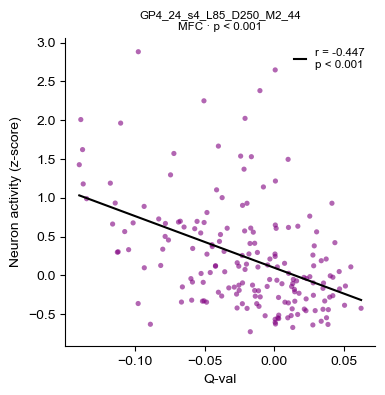

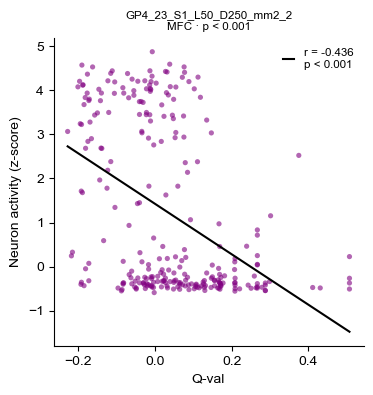

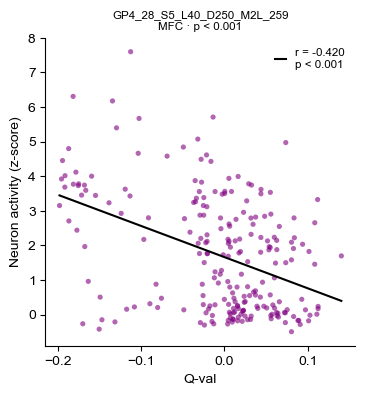

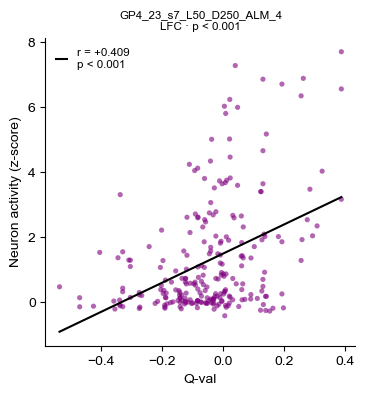

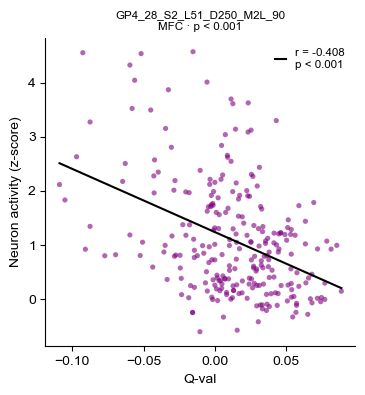

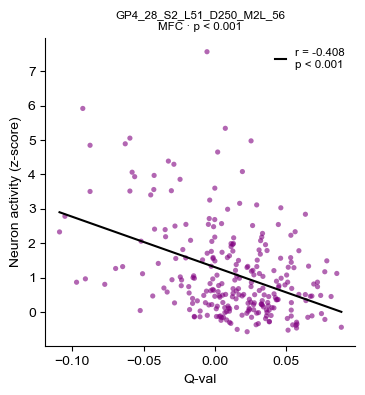

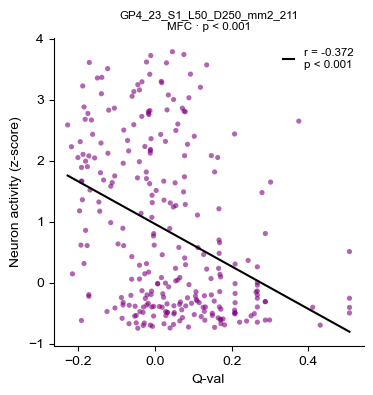

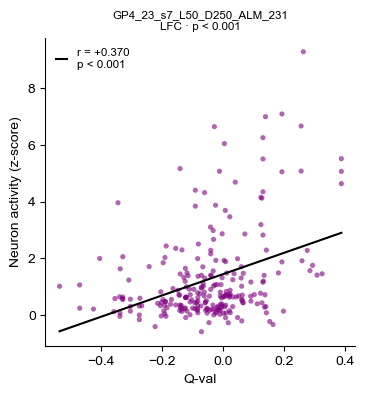

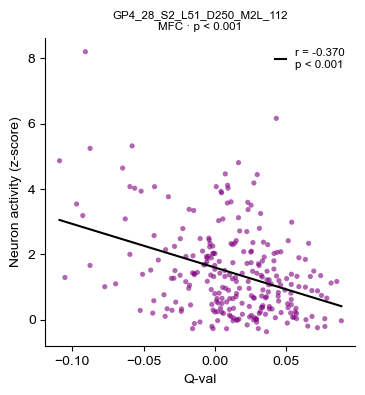

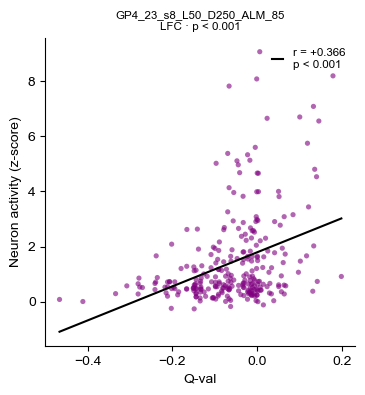

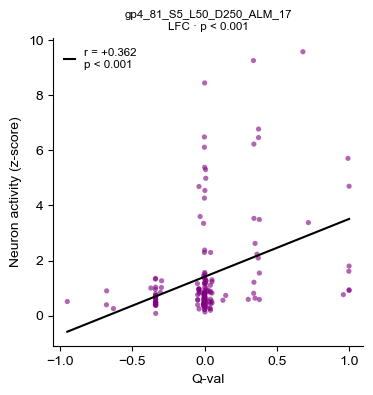

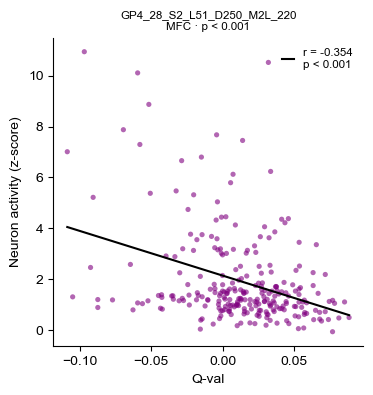

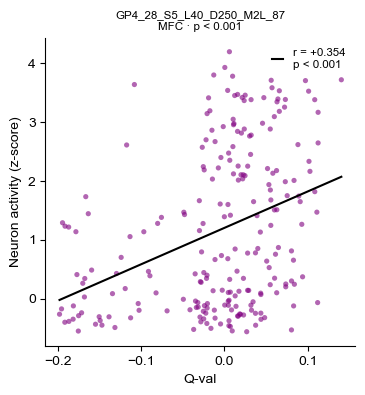

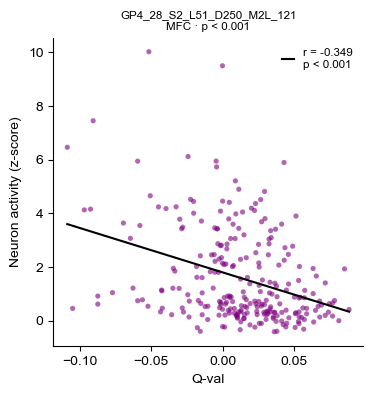

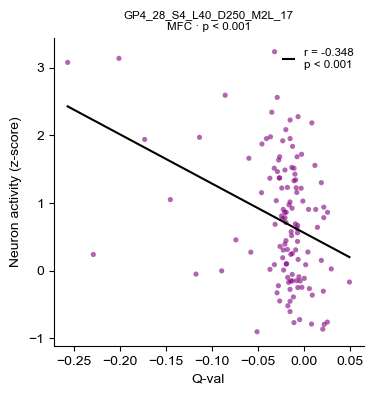

In [42]:
_ = nc.plot_neuron_results(table, corr_df, PARAM, mode="display",
                           top_x=TOP_X, zscore=ZSCORE_ACTIVITY)

In [43]:
# Save each TUNED neuron's scatter (|r| >= MIN_ABS_CORR) for EVERY parameter:
#   {BASE_SAVE_PATH}/{model}/traces/{param}/{signed_r}_{long_name}[_region].svg
# Gated by (SAVE_FIGS and not PAPER_FIGURES_ONLY) (Config) — one file per tuned neuron.
if SAVE_FIGS and not PAPER_FIGURES_ONLY:
    for key in PARAM_KEYS:
        nc.plot_neuron_results(table, corr_df, key, mode="save",
                               zscore=ZSCORE_ACTIVITY, min_abs_corr=MIN_ABS_CORR,
                               save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

Saved 46 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\traces\Q_L
Saved 78 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\traces\Q_R
Saved 47 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\traces\Q_val
Saved 91 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\traces\RewardRate


## Per-neuron trace averages by parameter value range

For each neuron, the time-normalized trace is averaged (mean ± SEM) within each
value range of `PARAM` (from `PARAM_VALUE_RANGES`), all overlaid in one axes and
gradient-coloured (pale → the parameter's bar colour). Dashed lines mark
sampling start and movement start. `mode="display"` shows the top-`TOP_X`
neurons; `mode="save"` writes the tuned subset (`|r| >= MIN_ABS_CORR`) under
`{model}/param_traces/{param}/`.

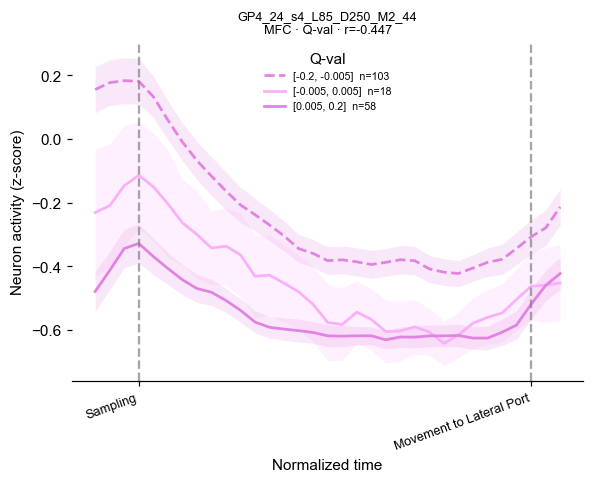

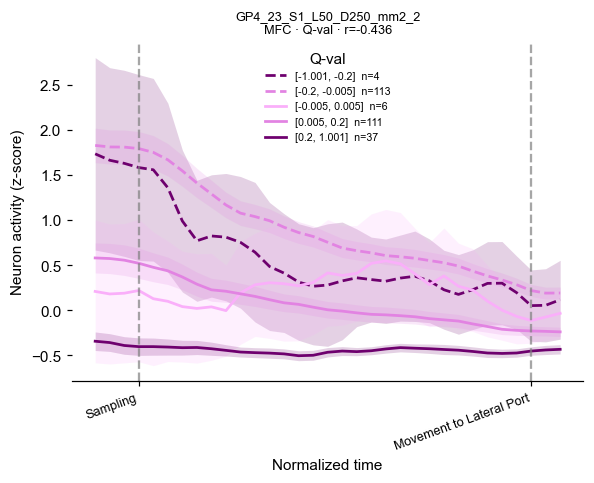

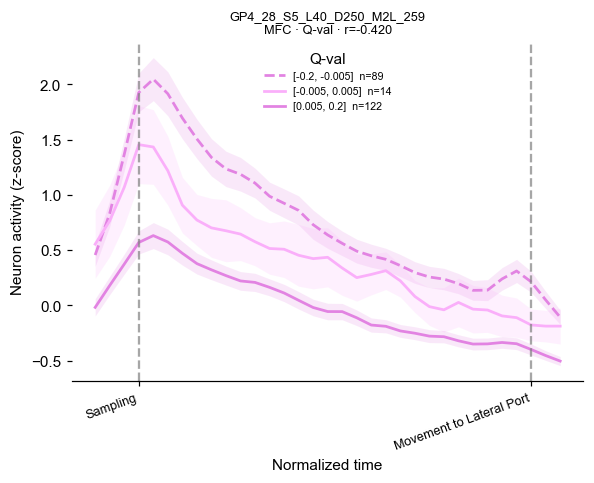

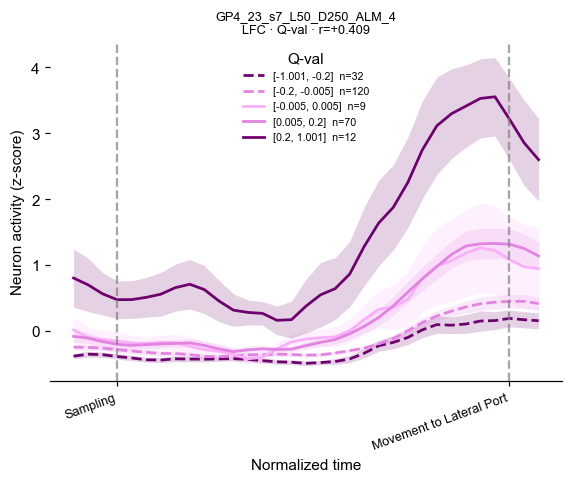

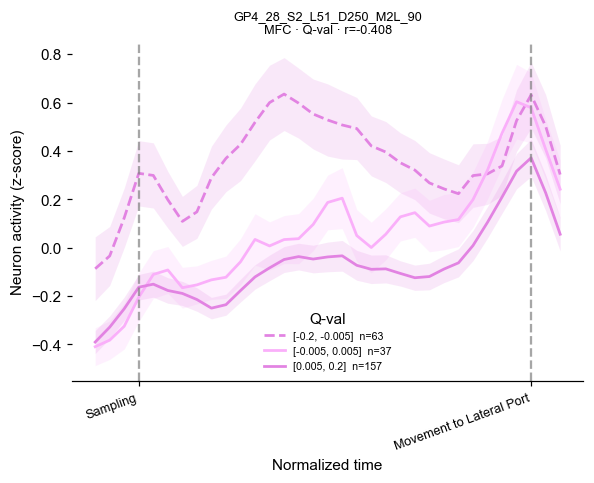

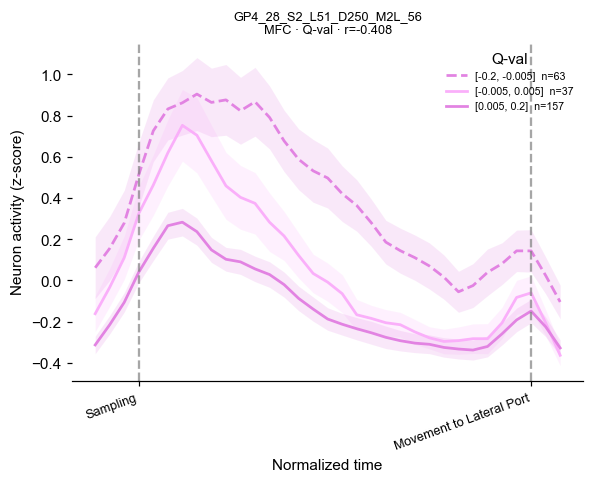

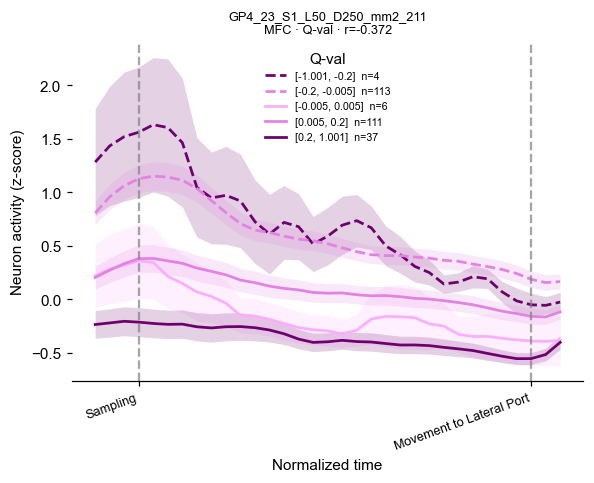

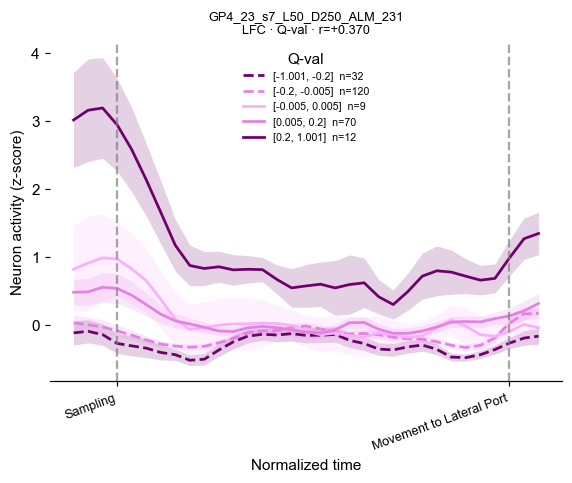

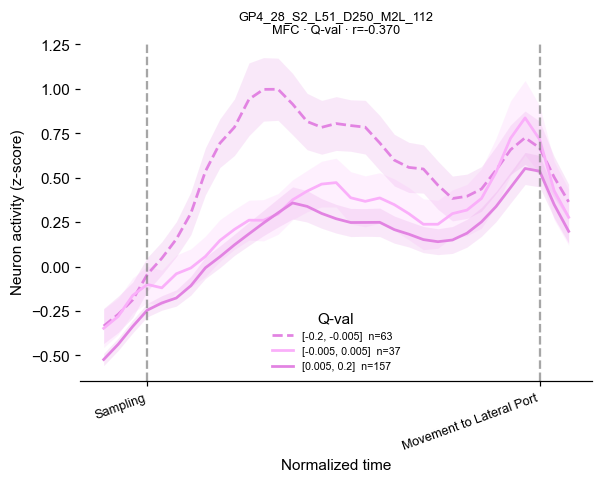

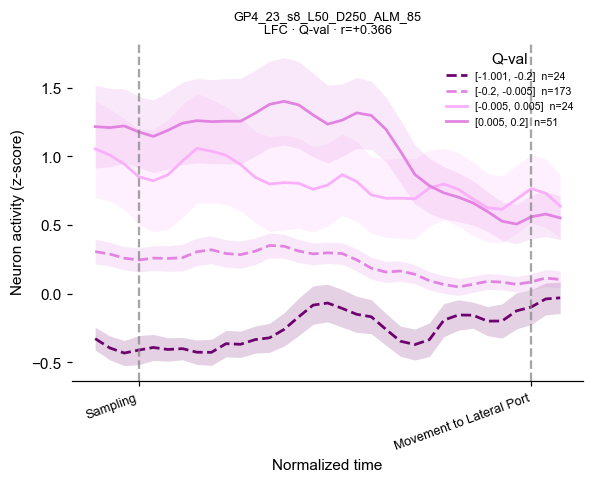

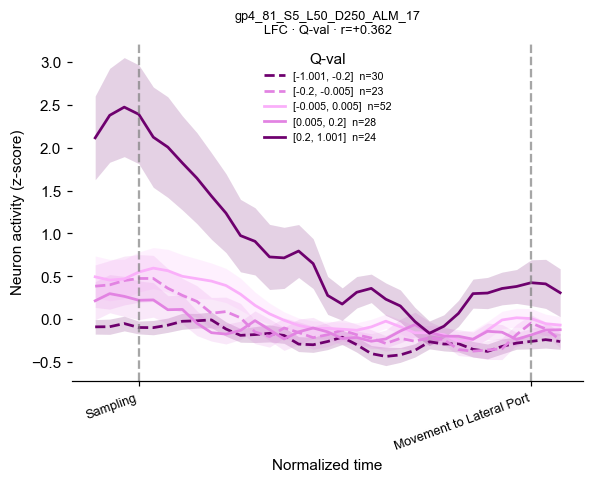

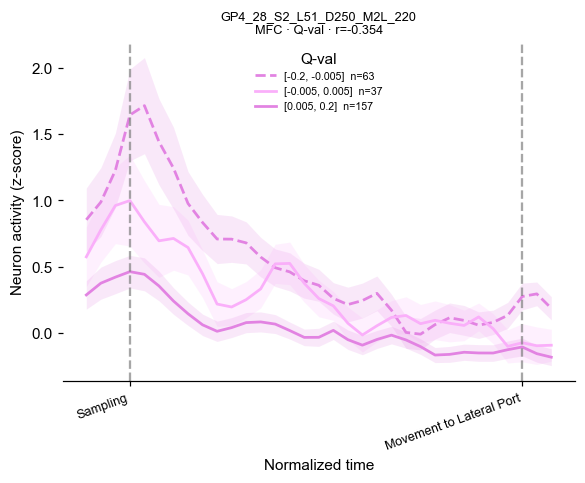

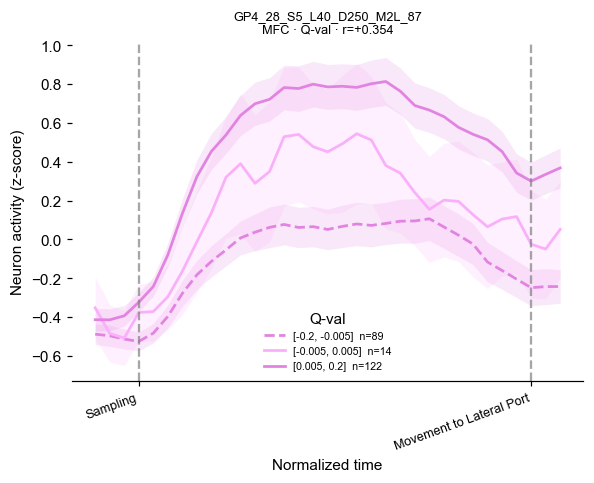

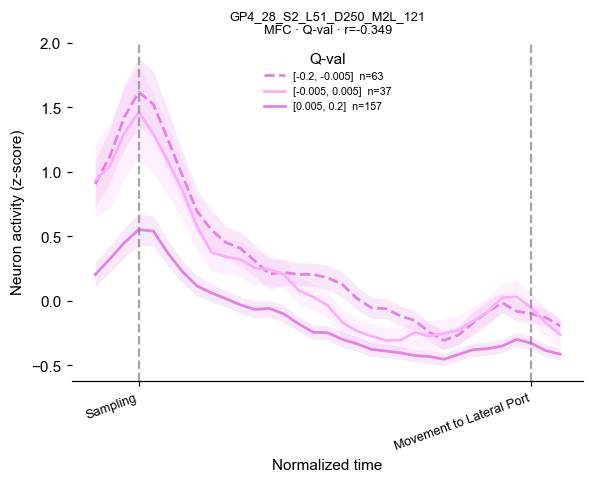

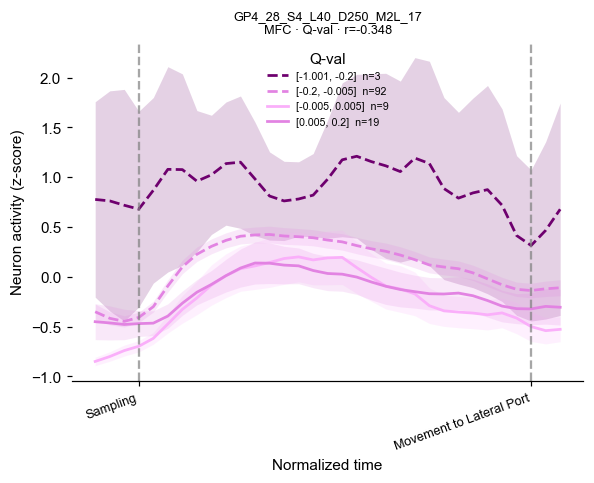

In [44]:
# Display the top-TOP_X tuned neurons' range-averaged traces for PARAM:
# _PARAM = "Q_R"
_PARAM = PARAM
_ = nc.plot_neuron_param_traces(table, corr_df, _PARAM, PARAM_VALUE_RANGES[_PARAM],
                                mode="display", top_x=TOP_X)


In [45]:
# Save the tuned subset for every parameter:
#   {BASE_SAVE_PATH}/{model}/param_traces/{param}/{signed_r}_{long_name}[_region].svg
# Gated by (SAVE_FIGS and not PAPER_FIGURES_ONLY) (Config) — one file per tuned neuron.
if SAVE_FIGS and not PAPER_FIGURES_ONLY:
    for key in PARAM_KEYS:
        nc.plot_neuron_param_traces(table, corr_df, key, PARAM_VALUE_RANGES[key],
                                    mode="save", min_abs_corr=MIN_ABS_CORR,
                                    save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

Saved 46 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\param_traces\Q_L
Saved 78 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\param_traces\Q_R
Saved 47 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\param_traces\Q_val
Saved 91 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\param_traces\RewardRate


## Fraction-tuned bars (per brain region)

One coloured bar per parameter = the % of tuned neurons, **session mean ± SEM**
(the distribution of per-session percentages within a region). Each bar is
tested against a per-neuron activity-shuffle chance level (`N_SHUFFLES`
permutations, `+1/(n+1)` p-value); the p-values are Holm-corrected across the
bars of a panel and shown as `*/**/***` (`n.s.` otherwise). `by_region=True`
gives one panel per MFC/LFC; `by_region=False` pools everything. Set
`RUN_STATS=False` (Config) to skip the permutation for a fast plot-only pass.
Always shown; `save=True` also writes the figure + summary under
`{model}/tuning_bars/`.

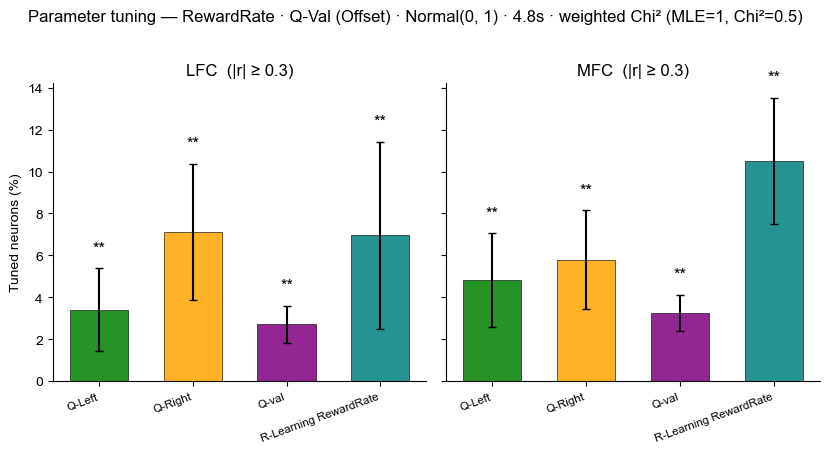

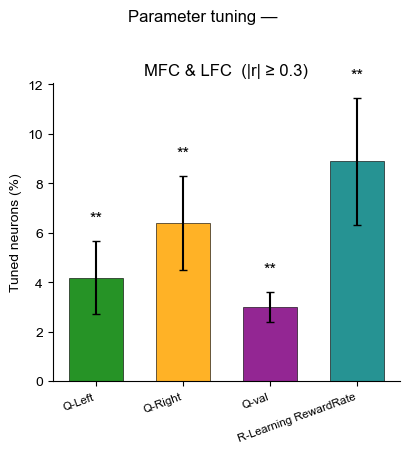

,BrainRegion,param,observed_pct,observed_sem,shuffle_pct,ci2.5,ci97.5,n_sessions,p_vs_shuffle,p_vs_shuffle_holm
0,LFC,Q_L,3.411945,1.967907,0.004262,0.0,0.000000,10,0.000999,0.003996
1,LFC,Q_R,7.122861,3.243592,0.003120,0.0,0.000000,10,0.000999,0.003996
2,LFC,Q_val,2.717979,0.886136,0.002605,0.0,0.000000,10,0.000999,0.003996
3,LFC,RewardRate,6.957827,4.456890,0.001934,0.0,0.000000,10,0.000999,0.003996
4,MFC,Q_L,4.827491,2.232300,0.014753,0.0,0.193798,12,0.000999,0.003996
5,MFC,Q_R,5.799032,2.342428,0.010095,0.0,0.166667,12,0.000999,0.003996
6,MFC,Q_val,3.259237,0.867129,0.017992,0.0,0.193798,12,0.000999,0.003996
7,MFC,RewardRate,10.500616,3.026633,0.007590,0.0,0.193798,12,0.000999,0.003996


In [46]:
# One bar per parameter, split by brain region, with the neuron-level shuffle
# baseline + permutation p-value. Needs `table` (per-trial data) for the shuffle.
# Significance (*/**/***) is Holm-corrected across the bars of each panel; set
# RUN_STATS=False in Config for a fast plot-only pass.
summary = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR,
                              n_shuffles=N_SHUFFLES, by_region=True,
                              run_stats=RUN_STATS, save=SAVE_FIGS,
                              save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
# ... and pooled across regions (everything together):
_ = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR, save=False,
                        n_shuffles=N_SHUFFLES, by_region=False,
                        run_stats=RUN_STATS)
summary

## Factor modulation bars (Q / Reward-Rate / DV, all trials)

Collapse related parameters into one **modulation factor**: a neuron is modulated
by a factor when `|r| >= MIN_ABS_CORR` for **any** of its params — counted
**once** (the correlation df is one row per neuron, so a neuron tuned to two Q
params is not double-counted). Three views:

1. **DV** alone, over **all** trials (the same drift as the fast/slow section
   below, but not split);
2. **Q** = Q-left/right/val collapsed into one "Q-modulated" bar;
3. **Q vs Reward-Rate vs DV** side by side, with **DV split into fast | slow**
   touching sub-bars (correlated *within* each RT tercile).

Bars are session mean ± SEM. In every view the significance stars test each bar
against its per-neuron activity-shuffle chance level (Holm across the bars). For
(3) the by-region view draws **MFC and LFC as two separate figures** sharing one
y-range (no cross-region comparison): the vs-chance stars are Holm-corrected
across the 4 bars *within each region*, and a session-paired **DV fast-vs-slow**
permutation bracket sits over the DV pair. `corr_all` adds DV to the correlations
(`PARAM_KEYS + ["DV"]`). Set `RUN_STATS=False` (Config) to skip all tests.

In [47]:
# DV lives on the 2P trial row (not the MLE latents), so add it to the
# correlations here. corr_all = the per-neuron r/p for Q_L/Q_R/Q_val/RewardRate
# AND DV, so the factor bars below can group across them.
corr_all = nc.compute_neuron_correlations(table, PARAM_KEYS + ["DV"])
corr_all.head()

,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,Q_L_r,Q_L_p,Q_R_r,Q_R_p,Q_val_r,Q_val_p,RewardRate_r,RewardRate_p,DV_r,DV_p
0,1,GP4_23_S1_L50_D250_mm2_1,MFC,GP4_23_S1_L50_D250_mm2,271,0.154442,0.010897,-0.095718,1.159395e-01,0.156797,9.730029e-03,0.013244,0.828190,0.109594,0.071665
1,10,GP4_23_S1_L50_D250_mm2_10,MFC,GP4_23_S1_L50_D250_mm2,271,0.221199,0.000242,-0.131668,3.023826e-02,0.234906,9.464234e-05,0.086711,0.154584,0.061417,0.313777
2,101,GP4_23_S1_L50_D250_mm2_101,MFC,GP4_23_S1_L50_D250_mm2,271,0.014938,0.806624,0.238310,7.426831e-05,-0.161772,7.621569e-03,0.165790,0.006227,0.015831,0.795311
3,1011,GP4_23_S1_L50_D250_mm2_1011,MFC,GP4_23_S1_L50_D250_mm2,271,-0.109787,0.071166,0.410447,1.948301e-12,-0.340336,8.962318e-09,0.216813,0.000324,0.018886,0.756940
4,1018,GP4_23_S1_L50_D250_mm2_1018,MFC,GP4_23_S1_L50_D250_mm2,271,0.179979,0.002945,-0.080341,1.873049e-01,0.184777,2.257411e-03,0.130244,0.032088,-0.031441,0.606332


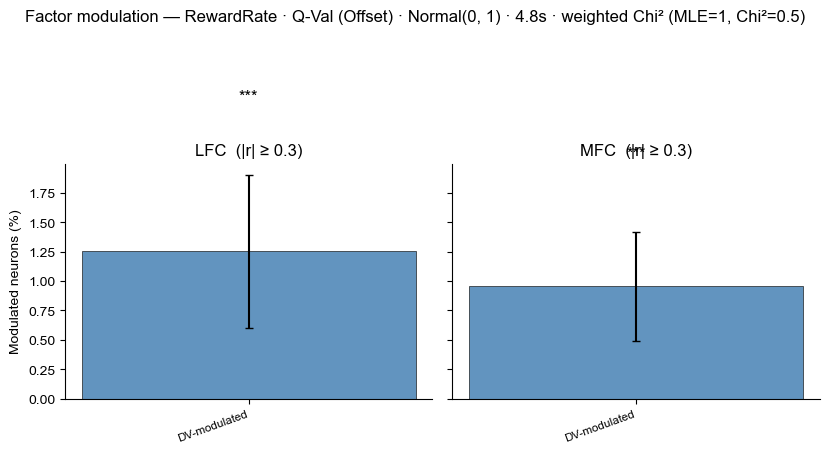

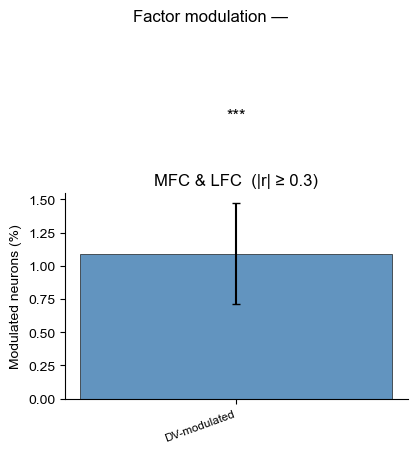

In [48]:
# (1) DV over ALL trials (not split fast/slow): % DV-modulated neurons, per
# region + pooled, vs the neuron-level shuffle chance baseline.
dv_factor = [nc.Factor("DV", ("DV",), "DV-modulated", "steelblue")]
_ = nc.plot_factor_bars(corr_all, table, dv_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=True, run_stats=RUN_STATS,
                        save=SAVE_FIGS, save_root=BASE_SAVE_PATH,
                        model_name=MODEL_NAME)
_ = nc.plot_factor_bars(corr_all, table, dv_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=False, run_stats=RUN_STATS)

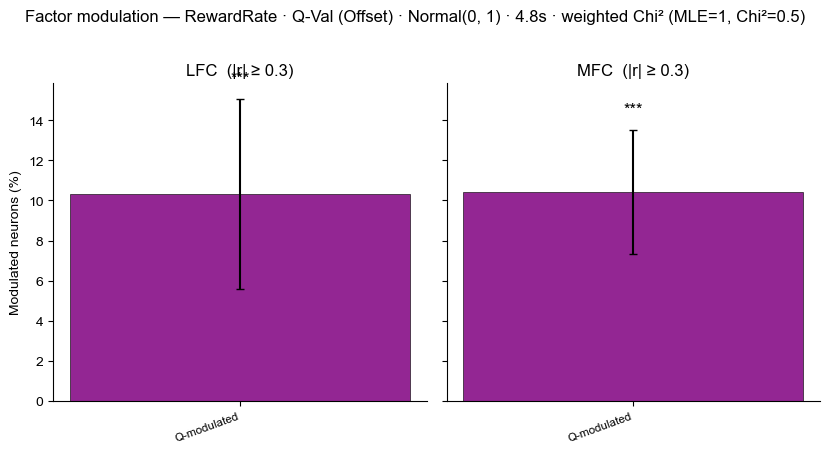

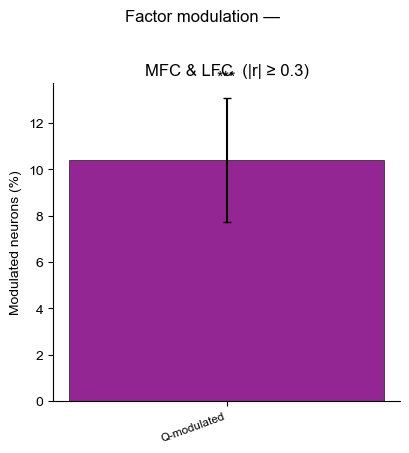

In [49]:
# (2) Q-modulated neurons: Q-left / Q-right / Q-val collapsed into ONE bar. A
# neuron counts if |r| >= MIN_ABS_CORR for any of the three (counted once, since
# corr_all is one row per neuron). Per region + pooled.
q_factor = [nc.Factor("Q", ("Q_L", "Q_R", "Q_val"), "Q-modulated", "purple")]
_ = nc.plot_factor_bars(corr_all, table, q_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=True, run_stats=RUN_STATS,
                        save=SAVE_FIGS, save_root=BASE_SAVE_PATH,
                        model_name=MODEL_NAME)
_ = nc.plot_factor_bars(corr_all, table, q_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=False, run_stats=RUN_STATS)

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fi

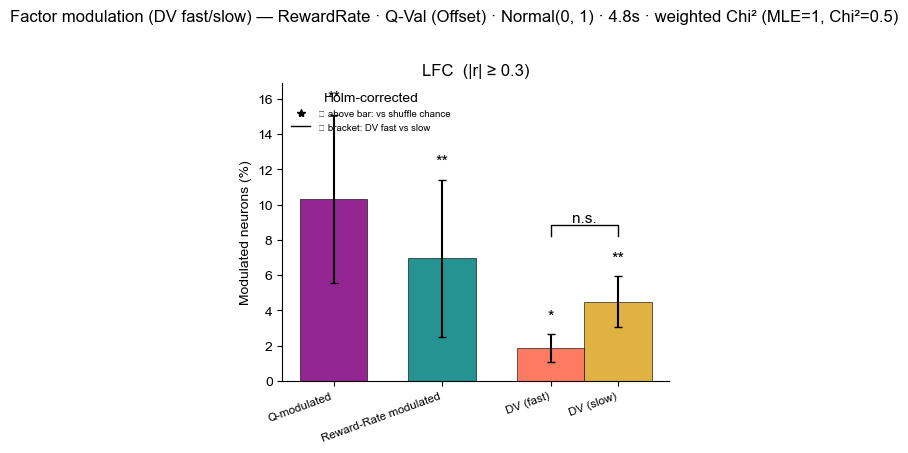

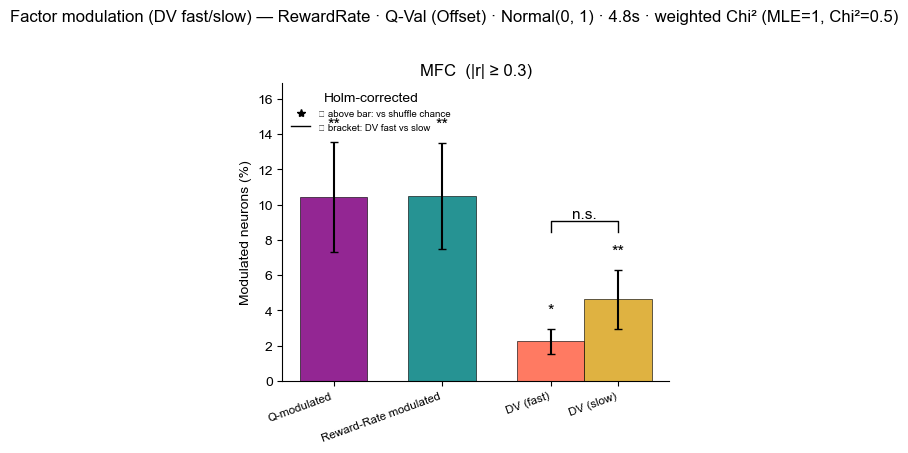

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1662: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


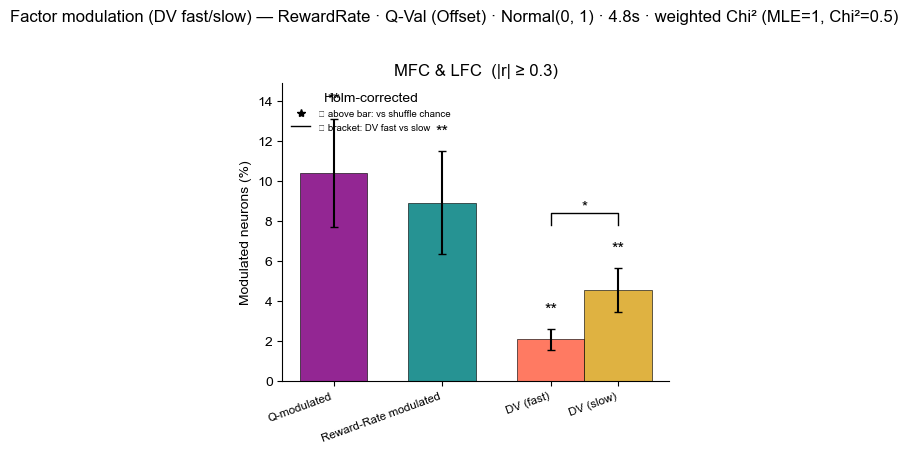

In [50]:
# (3) Compare the main decision drivers side by side: Q-modulated vs
# Reward-Rate-modulated vs DV, with DV split into fast (tomato) | slow
# (goldenrod) TOUCHING sub-bars. DV fast/slow are the % DV-correlated neurons
# WITHIN each RT-tercile subset. With by_region=True each region (MFC, LFC) is
# drawn as its OWN figure on a shared y-range (no cross-region comparison); each
# bar's star tests it vs its per-neuron activity-shuffle chance level (Holm
# across the 4 bars within that region), and the bracket over the DV pair is the
# session-paired DV fast-vs-slow permutation. by_region=False is a single pooled
# figure with the same vs-chance stars.
_ = nc.plot_factor_bars_fastslow_dv(corr_all, table, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, n_perm=N_PERM,
                        by_region=True, run_stats=RUN_STATS, save=SAVE_FIGS,
                        save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
# ... and pooled across regions:
_ = nc.plot_factor_bars_fastslow_dv(corr_all, table, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, n_perm=N_PERM,
                        by_region=False, run_stats=RUN_STATS,
                        save=SAVE_FIGS, save_root=BASE_SAVE_PATH,
                        model_name=MODEL_NAME)

# Fast vs slow: drift-correlated neurons

Same tuned criterion (Pearson r of per-trial max activity vs the drift value,
`|r| >= MIN_ABS_CORR`), but the drift value is the trial's **DV** (signed
evidence) and, separately, **DVabs** (=|DV|). Correlations are computed **within**
the fast (`quantile_idx==1`) and slow (`quantile_idx==3`) trial subsets
separately. The summary bars compare each region — and all regions pooled — fast
vs slow (session mean ± SEM), with permutation / bootstrap significance layered
on (see below).

In [51]:
# Per-neuron DV / DVabs correlations, computed within the fast and slow subsets.
corr_fast, corr_slow = nc.drift_correlations(table)
print("fast neurons:", len(corr_fast), " slow neurons:", len(corr_slow))
corr_fast.head()

fast neurons: 1392  slow neurons: 1392


,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,DV_r,DV_p,DVabs_r,DVabs_p
0,1,GP4_23_S1_L50_D250_mm2_1,MFC,GP4_23_S1_L50_D250_mm2,91,0.075227,0.478505,-0.113572,0.283765
1,10,GP4_23_S1_L50_D250_mm2_10,MFC,GP4_23_S1_L50_D250_mm2,91,0.163874,0.120623,-0.018690,0.860416
2,101,GP4_23_S1_L50_D250_mm2_101,MFC,GP4_23_S1_L50_D250_mm2,91,0.055950,0.598359,0.000022,0.999837
3,1011,GP4_23_S1_L50_D250_mm2_1011,MFC,GP4_23_S1_L50_D250_mm2,91,-0.098991,0.350532,-0.137028,0.195246
4,1018,GP4_23_S1_L50_D250_mm2_1018,MFC,GP4_23_S1_L50_D250_mm2,91,0.078422,0.459971,0.157178,0.136772


## Fast-vs-slow summary bars

Per-session % drift-correlated neurons, fast (tomato) vs slow (goldenrod), for
DV and DVabs. `by_region=True` → one fast/slow pair per MFC/LFC (4 bars);
`by_region=False` → all regions pooled (2 bars). Bars are session mean ± SEM.

Three significance layers (all Holm-corrected within their family, gated by
`RUN_STATS`): a **vs-chance** star above each bar (per-neuron activity shuffle —
needs `table`); a session-**paired fast-vs-slow** permutation bracket per region;
and, in the by-region view, **MFC-vs-LFC** hierarchical-bootstrap brackets within
each speed.

	LFC: fast 1.85±0.79% (10 sess) | slow 4.48±1.44% (10 sess)
	MFC: fast 2.25±0.71% (12 sess) | slow 4.62±1.67% (12 sess)


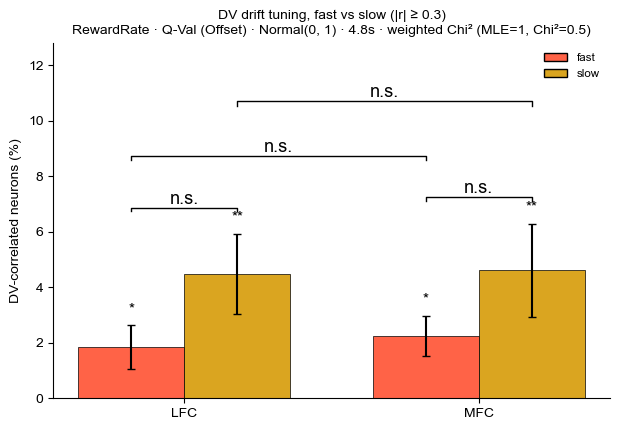

	MFC & LFC: fast 2.07±0.52% (22 sess) | slow 4.56±1.10% (22 sess)


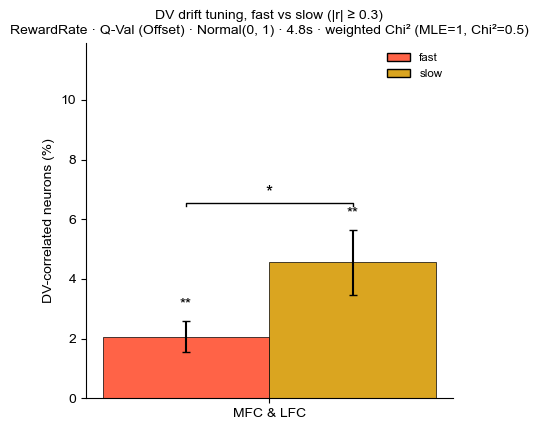

	LFC: fast 0.98±0.71% (10 sess) | slow 1.83±1.02% (10 sess)
	MFC: fast 1.27±0.99% (12 sess) | slow 2.09±1.16% (12 sess)


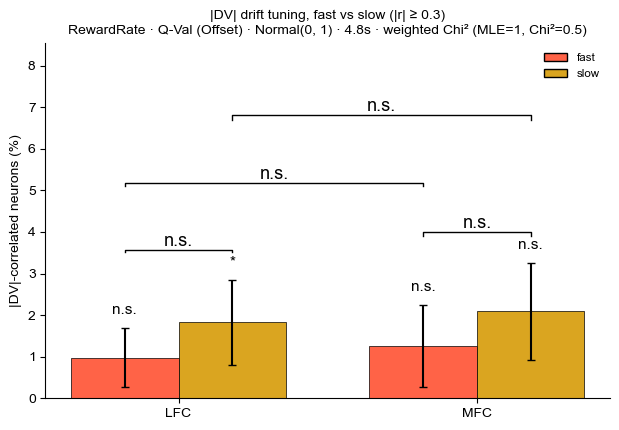

	MFC & LFC: fast 1.13±0.61% (22 sess) | slow 1.97±0.77% (22 sess)


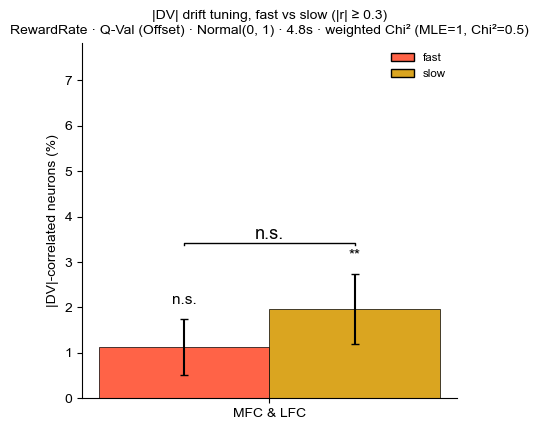

In [52]:
# Fast-vs-slow summary bars: per region (4 bars) and all-regions pooled (2 bars),
# for DV and for DVabs. Passing `table` enables the per-bar vs-chance shuffle
# test; each bar also carries a session-paired fast-vs-slow permutation, and the
# by-region view adds MFC-vs-LFC hierarchical-bootstrap brackets within each
# speed. Set RUN_STATS=False in Config for a fast plot-only pass.
for drift in ("DV", "DVabs"):
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, table=table,
                           min_abs_corr=MIN_ABS_CORR, n_perm=N_PERM, n_boot=N_BOOT,
                           by_region=True, run_stats=RUN_STATS,
                           save=SAVE_FIGS,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, table=table,
                           min_abs_corr=MIN_ABS_CORR, n_perm=N_PERM, n_boot=N_BOOT,
                           by_region=False, run_stats=RUN_STATS,
                           save=SAVE_FIGS,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow scatters

Fast (tomato) and slow (goldenrod) trials overlaid on one axes, each with its
own fit line + r/p. Neurons ranked by `max(|r_fast|, |r_slow|)`; display shows
the top-`TOP_X`, save writes the drift-correlated subset under
`{model}/drift_scatter/{drift}/`.

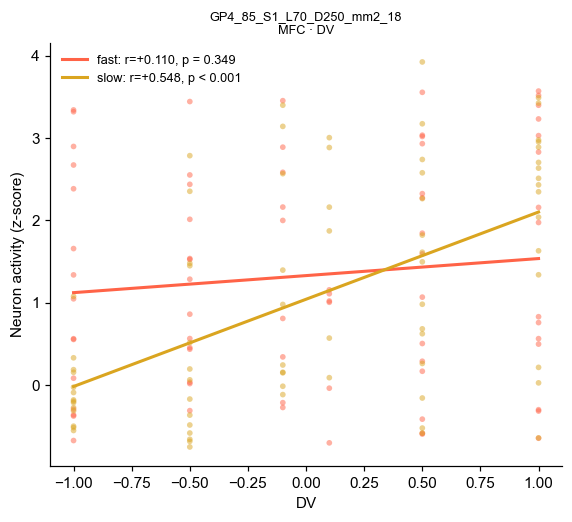

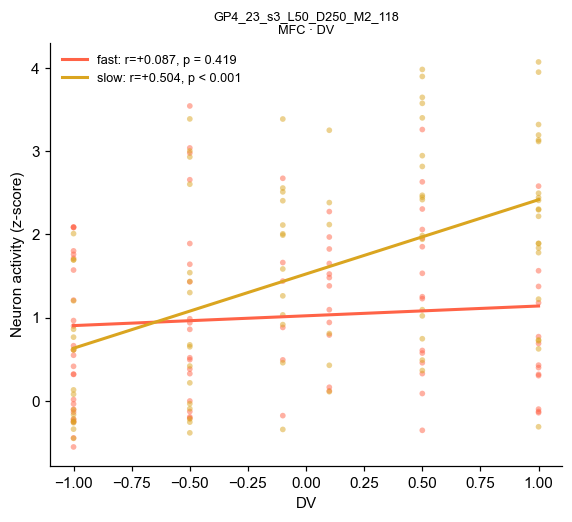

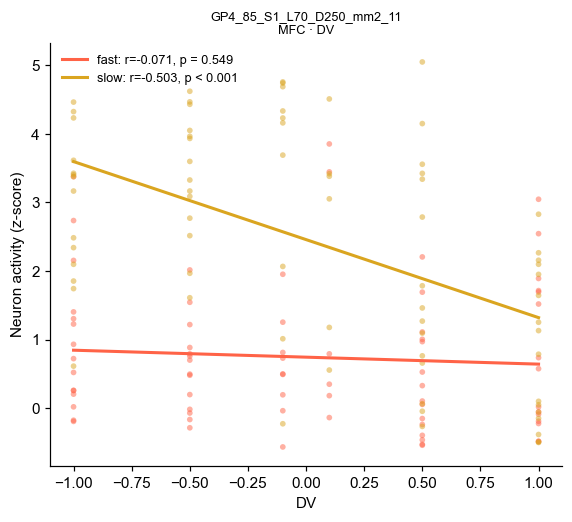

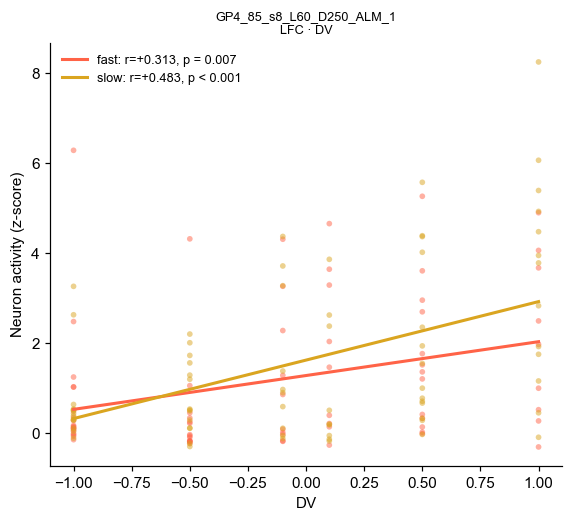

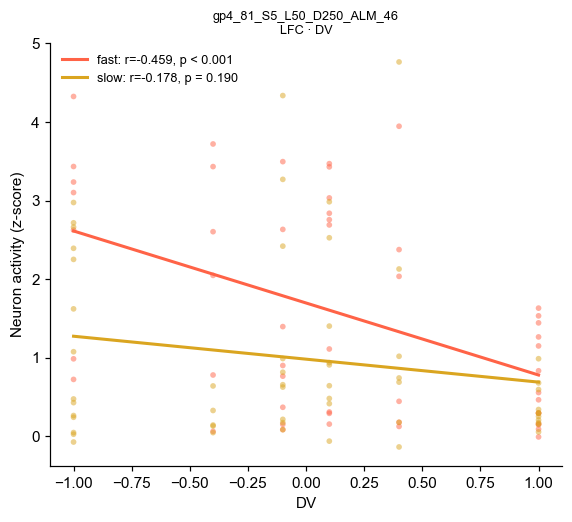

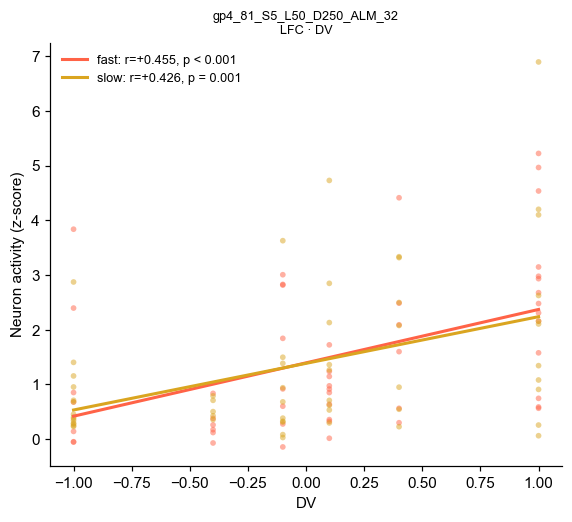

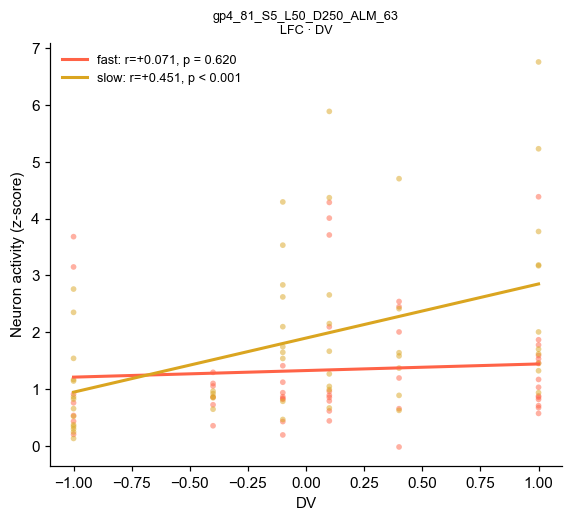

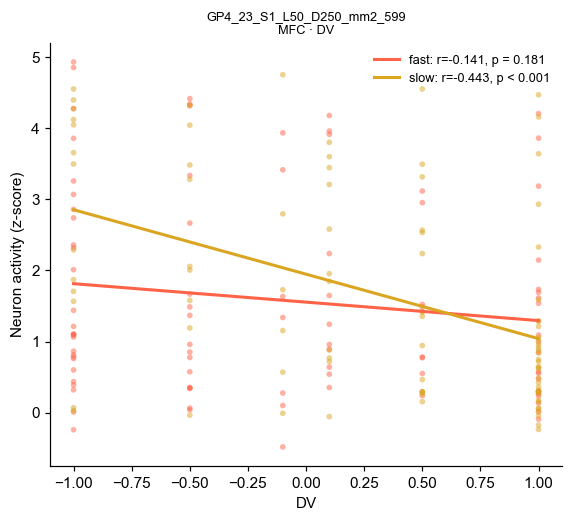

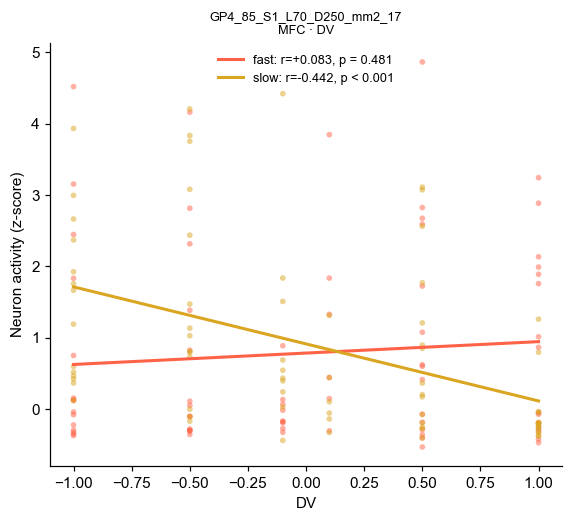

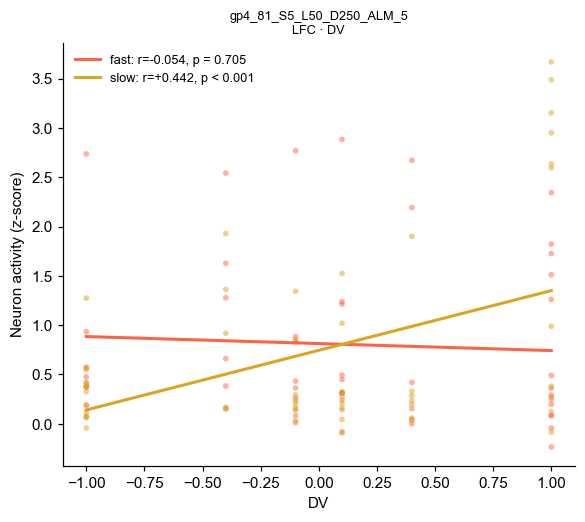

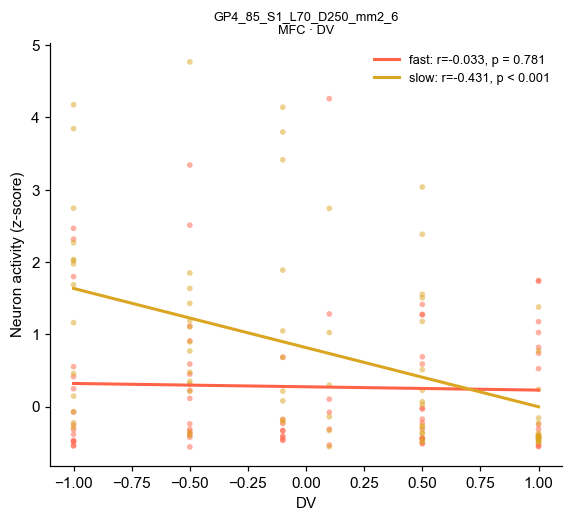

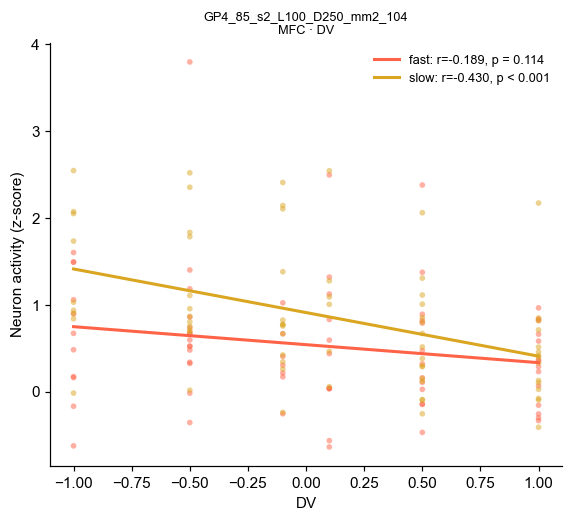

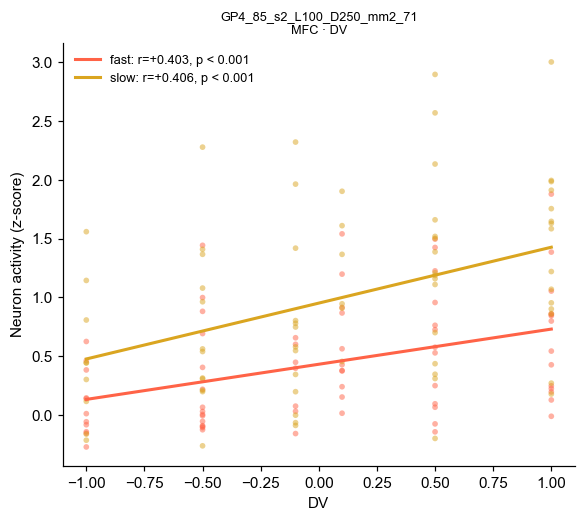

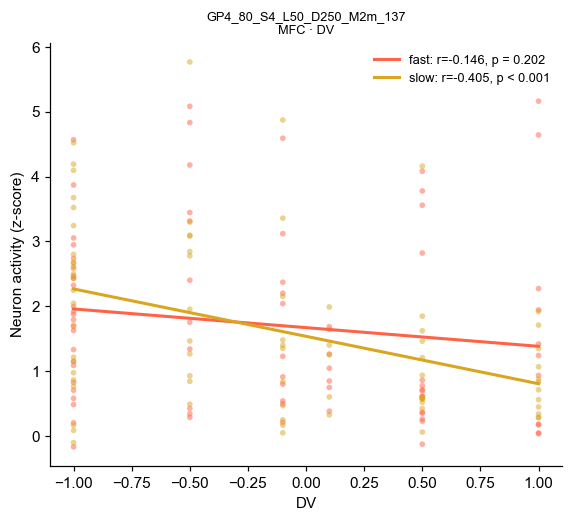

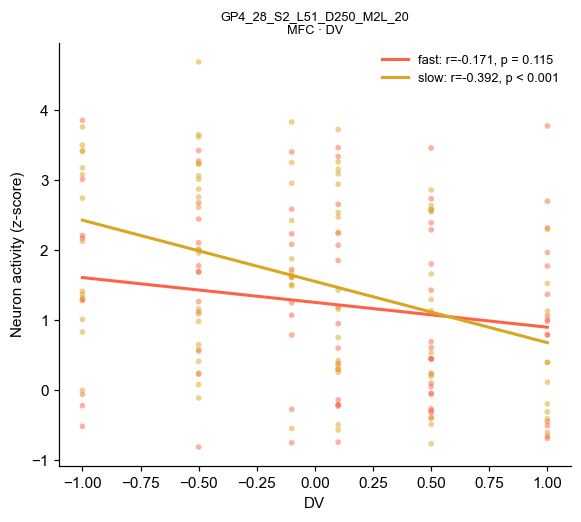

Saved 70 fast/slow scatters -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\drift_scatter\DV
Saved 30 fast/slow scatters -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\drift_scatter\DVabs


In [53]:
# Per-neuron scatters, fast (tomato) & slow (goldenrod) overlaid, top-TOP_X by
# max(|r_fast|, |r_slow|). Each speed gets its own fit line + r/p in the legend.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, _DRIFT,
                                    mode="display", top_x=TOP_X)

# Save the drift-correlated subset (max(|r_fast|,|r_slow|) >= MIN_ABS_CORR):
#   {BASE_SAVE_PATH}/{model}/drift_scatter/{drift}/f{rf}_s{rs}_{long_name}[_region].svg
# Gated by (SAVE_FIGS and not PAPER_FIGURES_ONLY) (Config) — one file per drift-correlated neuron.
if SAVE_FIGS and not PAPER_FIGURES_ONLY:
    for drift in ("DV", "DVabs"):
        nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, drift,
                                        mode="save", min_abs_corr=MIN_ABS_CORR,
                                        save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow traces

Two-panel (Fast | Slow) time-normalized traces, averaged within each
`DRIFT_VALUE_RANGES` bin and gradient-coloured. For the signed **DV**, the
gradient encodes only the range's magnitude (so ±1 share a shade) and the
negative-DV ranges are drawn dashed; **DVabs** is a plain light→dark gradient.

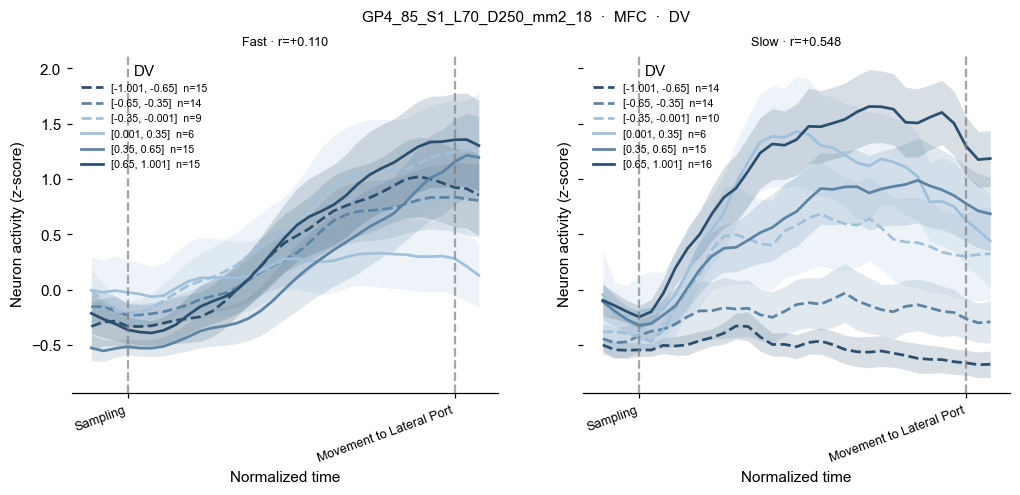

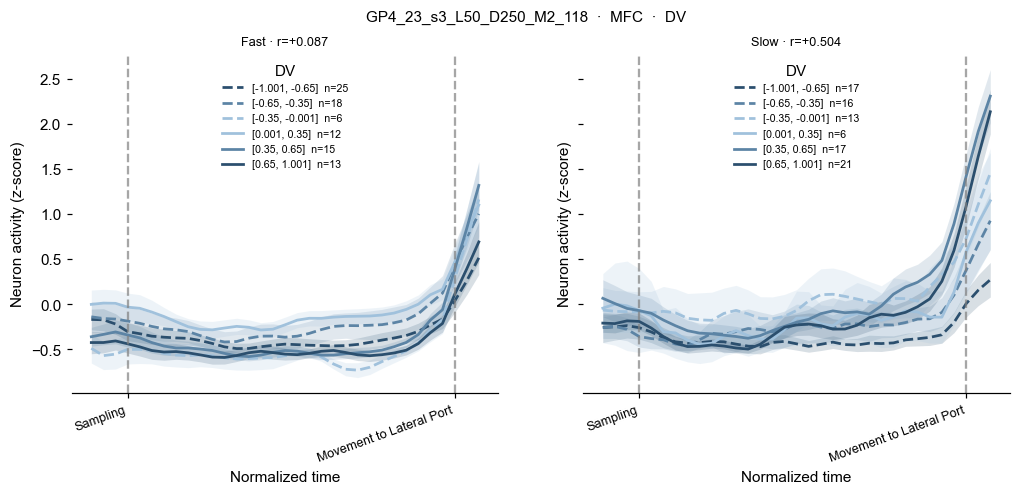

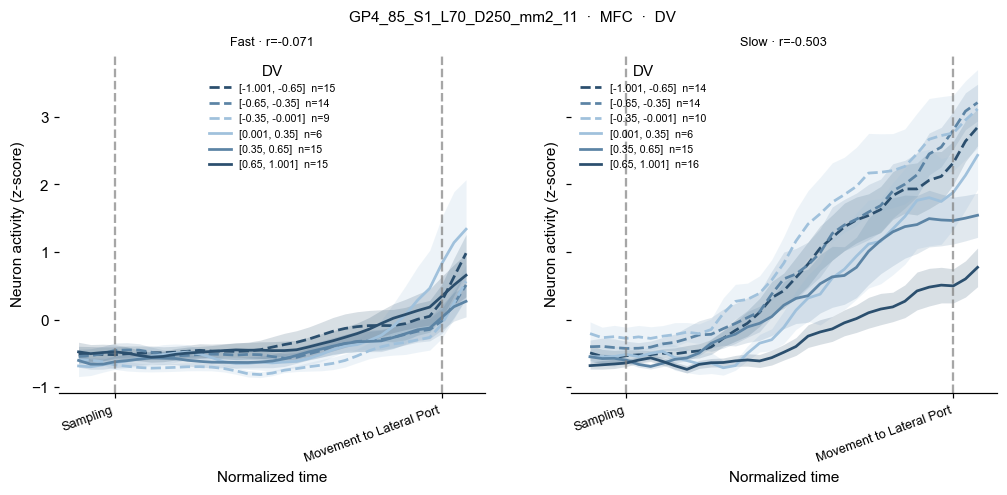

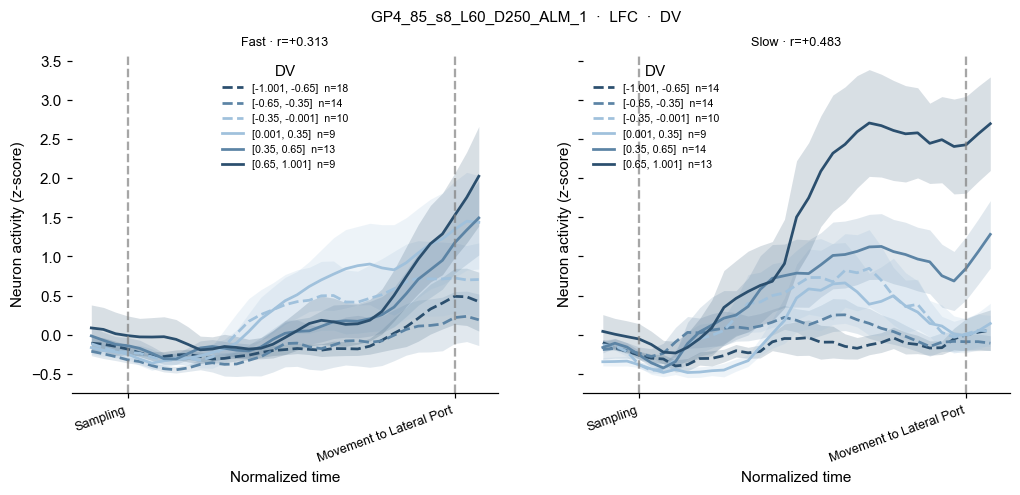

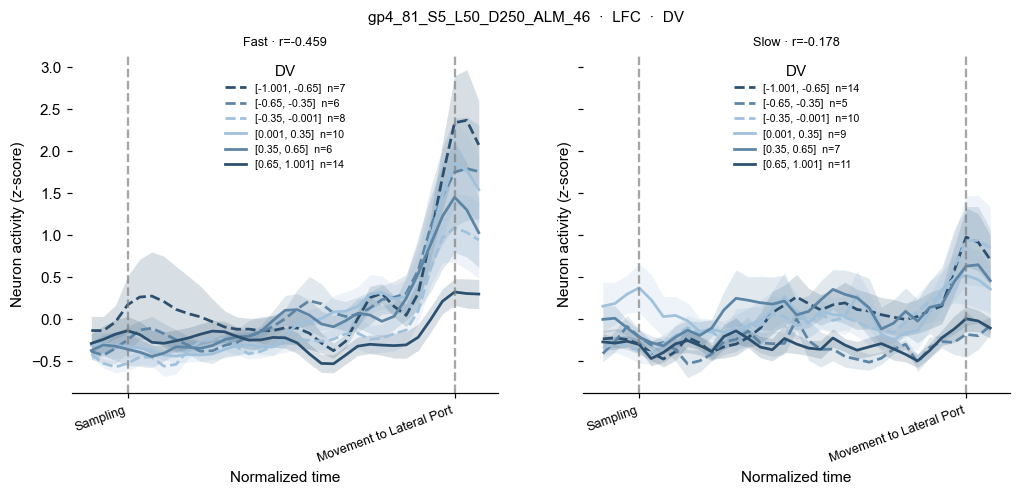

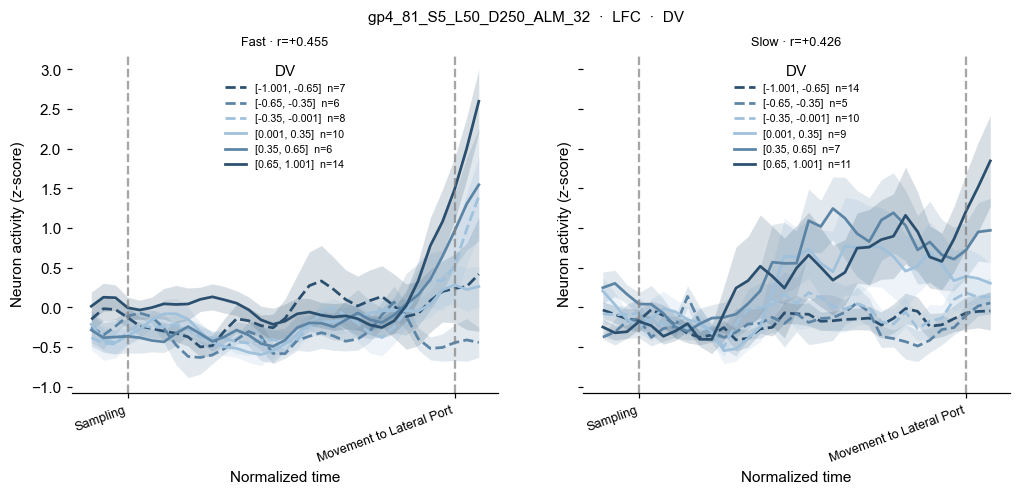

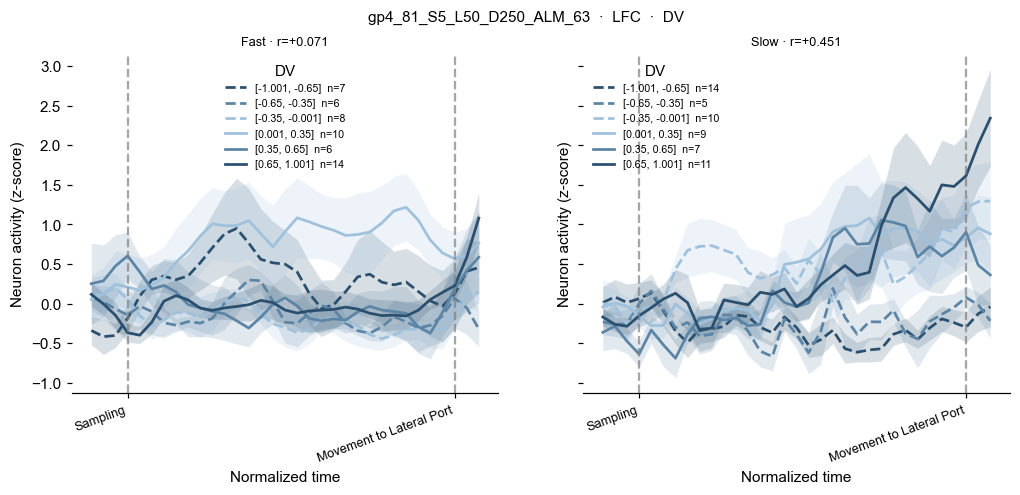

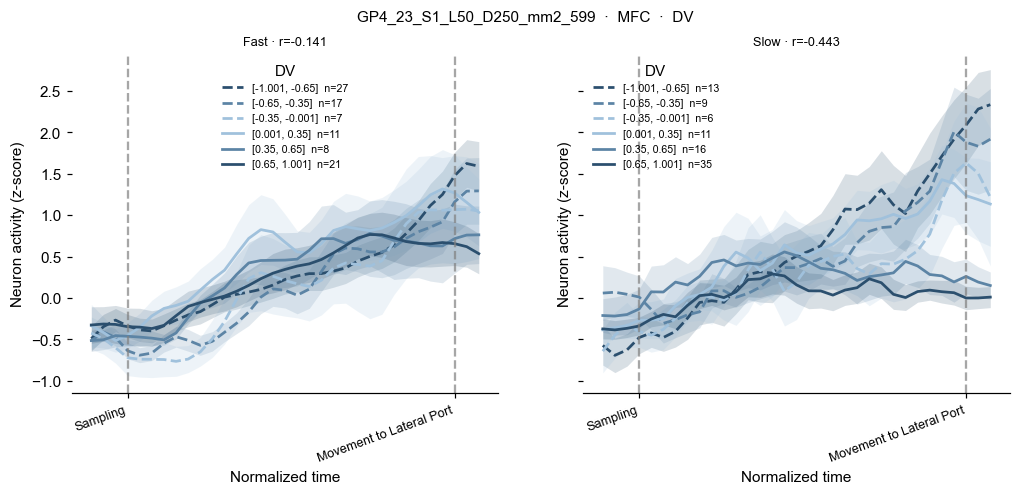

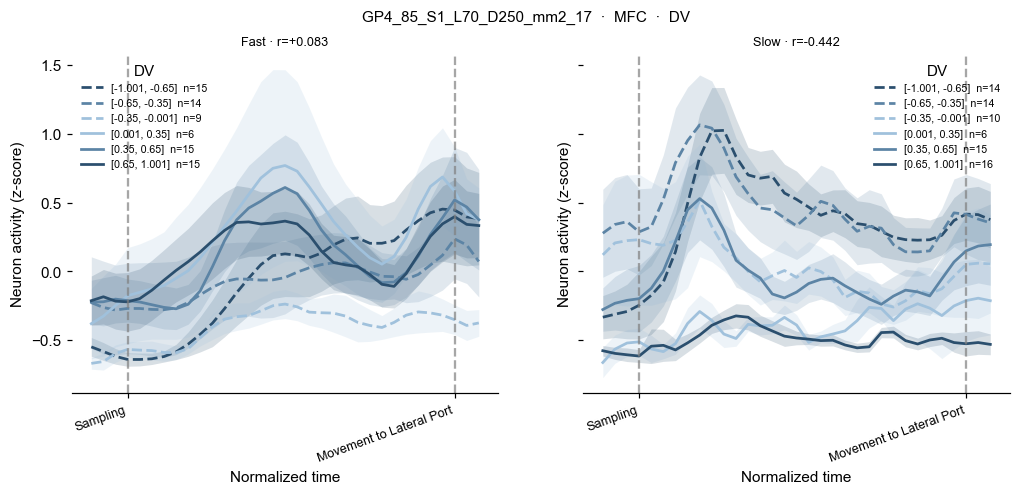

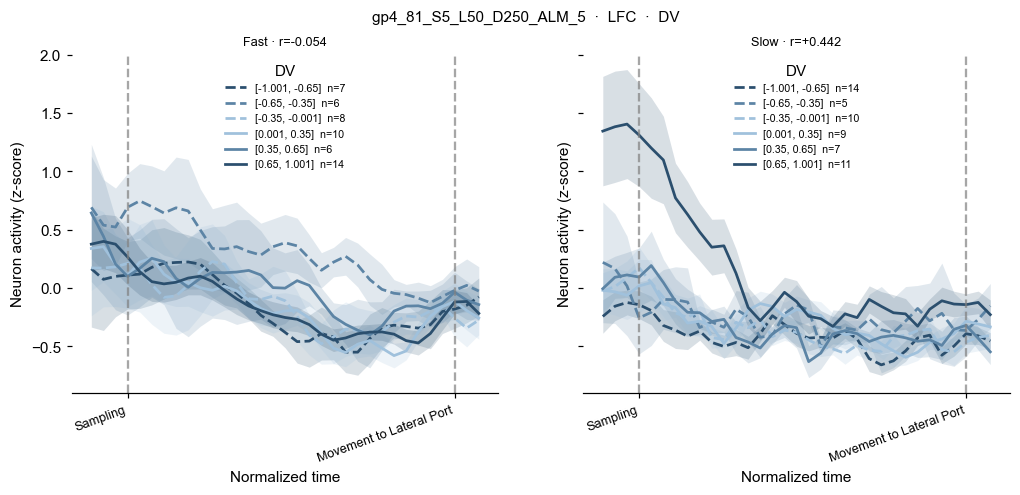

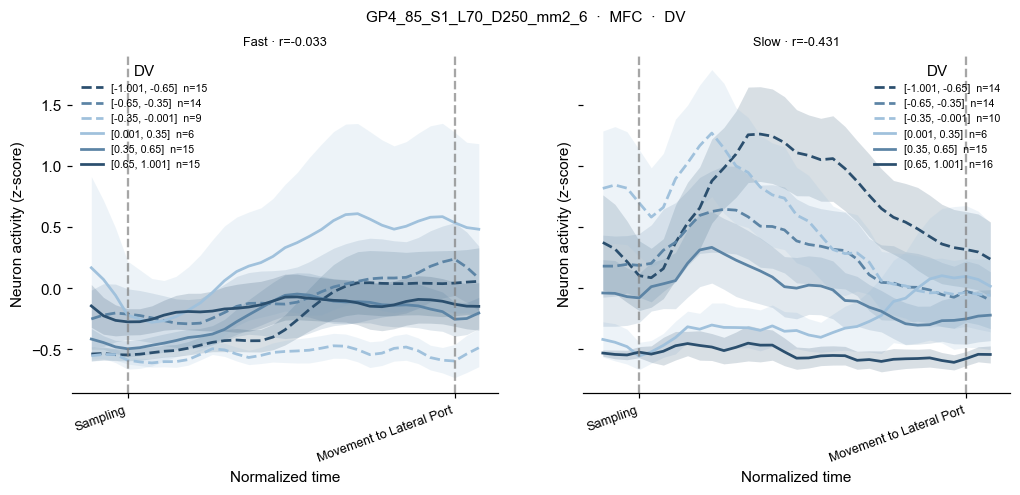

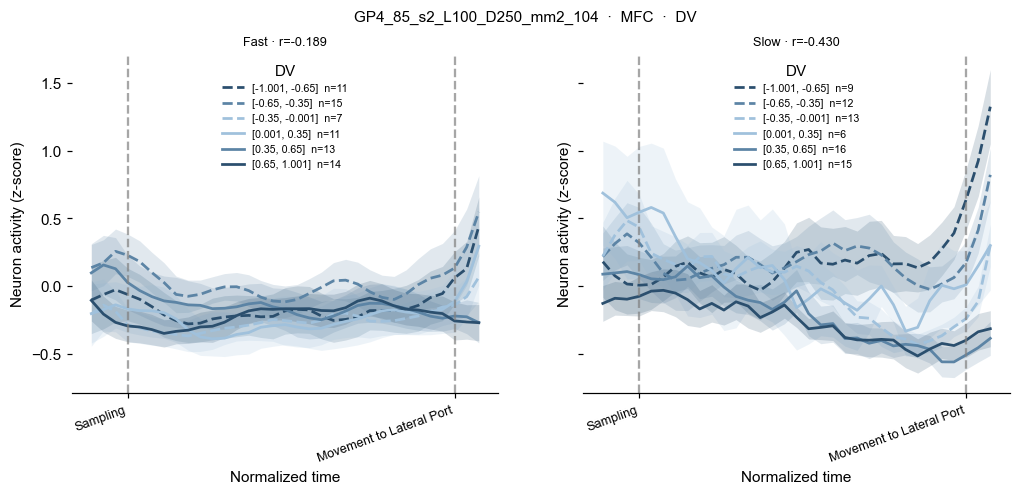

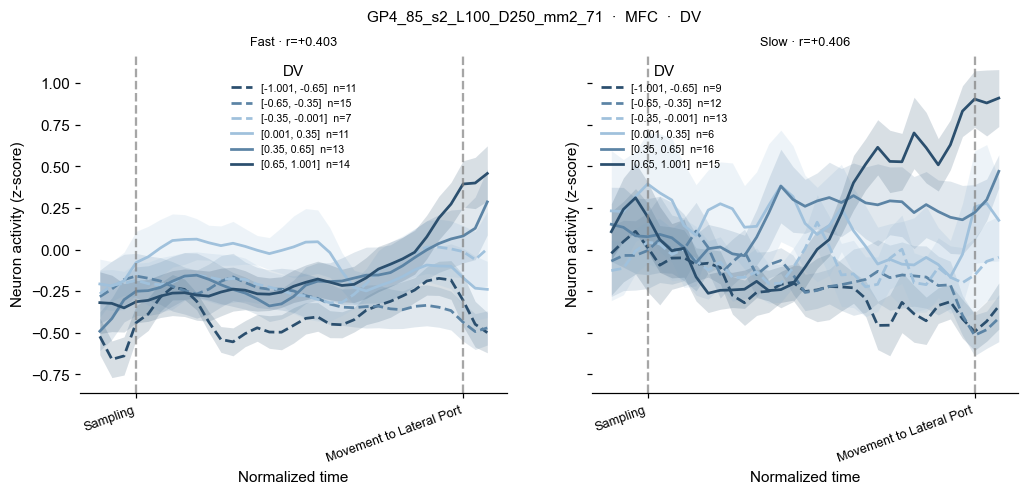

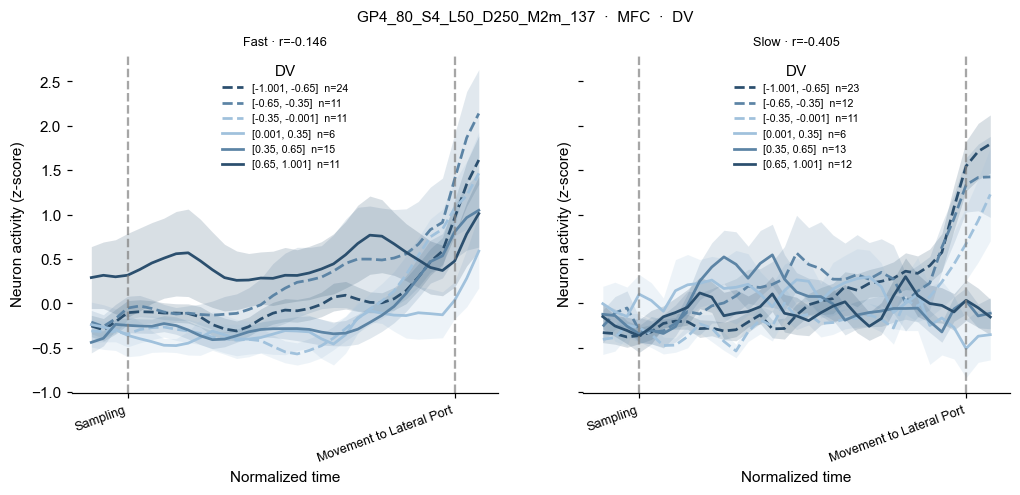

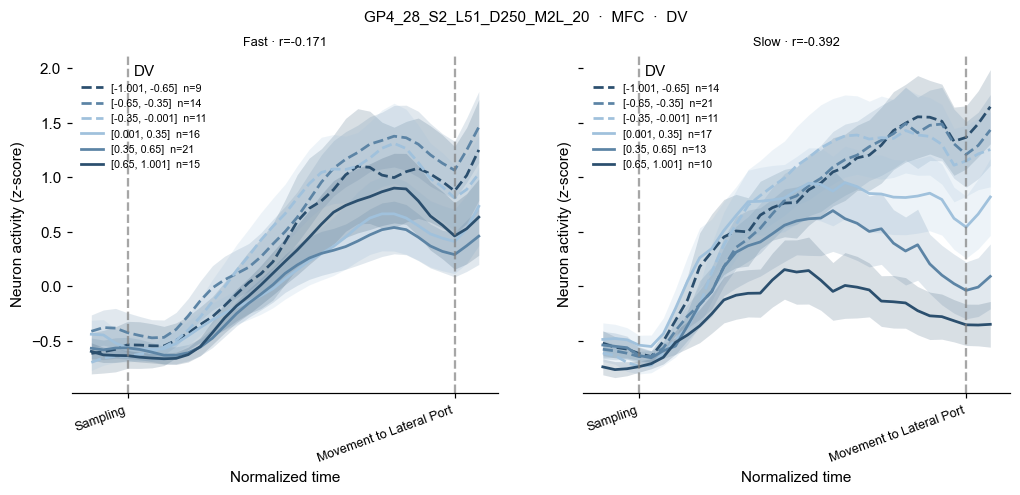

Saved 70 fast/slow trace figures -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\drift_traces\DV
Saved 30 fast/slow trace figures -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.5)\drift_traces\DVabs


In [54]:
# Per-neuron normalized traces, Fast | Slow two-panel, gradient by DRIFT range.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, _DRIFT,
                                   DRIFT_VALUE_RANGES[_DRIFT],
                                   mode="display", top_x=TOP_X)

# Save the drift-correlated subset under {model}/drift_traces/{drift}/:
# Gated by (SAVE_FIGS and not PAPER_FIGURES_ONLY) (Config) — one file per drift-correlated neuron.
if SAVE_FIGS and not PAPER_FIGURES_ONLY:
    for drift in ("DV", "DVabs"):
        nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, drift,
                                       DRIFT_VALUE_RANGES[drift], mode="save",
                                       min_abs_corr=MIN_ABS_CORR,
                                       save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

# Reward-rate levels: correlated neurons across reward rate

The reward-rate variation of the fast-vs-slow section above. There the trials
are split by RT tercile (fast / slow strategy); here they are split by the
model's **reward-rate latent**, and we ask the same question at each level: what
% of neurons are drift-correlated (`|r| >= MIN_ABS_CORR` for `DV` / `DVabs`,
Pearson, computed **within** that level's trials)?

Bars are the per-session %, session mean ± SEM, shaded pale → dark for low →
high reward rate. Two Holm-corrected significance layers (gated by `RUN_STATS`):
a **vs-chance** star above each bar (per-neuron activity shuffle, Holm across the
bars of a panel), and a bracket spanning the levels carrying the
**session-paired across-level test** (Holm across panels) — a paired t-test of
sessions for two levels, a repeated-measures ANOVA with session as the subject
factor beyond two, with Holm-corrected pairwise paired post-hocs appended to the
returned summary.

## How the trials are split (`RR_SPLIT_BY`)

**`"session_quantile"` — the default, and the right one here.** Each session is
cut at *its own* quantiles into equal-count levels (`RR_QUANTILES`, start with
3). The reward rate is a **fitted** latent, so its distribution differs from
session to session; a shared cut point therefore hands each session a different
number of trials per level, which does two bad things:

1. a session lying wholly on one side of the cut contributes to one bar but
   cannot be paired, so it is dropped from the test entirely;
2. levels end up with different trials-per-neuron, and since `r` is noisier with
   fewer trials, `|r| >= MIN_ABS_CORR` fires more often **by chance** in the
   sparse level — so the levels are not comparable even when every session
   survives.

Equal counts per session per level removes both. This is the same convention the
RT terciles already use (`behavior/util/splitdata.py`): sort the session's trials
and cut into equal-count parts, rather than binning by value.

**`"value"` — fixed cut points shared by all sessions.** Use it when the
*absolute* reward rate is what matters, and read the occupancy/coverage cell
carefully: it reports how many sessions each candidate split would cost. Note
that pooled quantile edges (`quantile_bin_edges`) balance the **totals** but are
still fixed cut points, so they do not fix problem (1).

`RR_COMMON_NEURONS` keeps every bar over the *same* neurons — those whose
correlation is defined at every level.


In [55]:
# HOW to split trials by reward rate. Three criteria:
#
#   "session_quantile_range"  Extremes in QUANTILE space. RR_QUANTILE_EXTREMES
#       is a list of (q_lo, q_hi) FRACTIONS with a gap between them; each session
#       is cut at ITS OWN quantiles, so the band tracks that session's
#       distribution instead of drifting into the crowded part of one session and
#       off the end of another. A run of TIED values is kept whole (both ends
#       closed), so the bands come out unequal in size rather than splitting
#       trials that share a reward rate across "low" and "high" — the right trade
#       for a latent that plateaus.
#
#   "session_quantile"  RR_QUANTILES is an INTEGER number of levels and each
#       session is cut into EXACTLY equal-count levels. Balanced by construction,
#       but it has to break ties by rank, so identical reward rates can land in
#       different levels. Same convention as the RT terciles
#       (behavior/util/splitdata.py).
#
#   "value"  Fixed cut points shared by every session: a flat sequence of EDGES
#       (np.arange or a list) or explicit (lo, hi) tuples; membership is
#       [lo, hi), last bin [lo, hi]. Use when the ABSOLUTE reward-rate value is
#       what matters, and accept the imbalance it brings — with a skewed latent
#       the sparse level gets so few trials per neuron that its |r| >= threshold
#       CHANCE RATE alone can exceed the dense level's observed rate.
RR_SPLIT_BY = "session_quantile_range"

# --- session_quantile_range: the bands, as quantile fractions ---
# Binary extremes; the middle 50% is dropped. Any number of gapped bands works,
# e.g. [(0, .2), (.4, .6), (.8, 1.)] for low / middle / high.
RR_QUANTILE_EXTREMES = [(0.0, 0.25), (0.75, 1.0)]

# --- session_quantile: just the number of levels ---
RR_QUANTILES = 3

# --- value: fixed cut points (used only when RR_SPLIT_BY == "value") ---
RR_BINS_BINARY = [0.0, 0.5, 1.0]                    # low vs high
RR_BINS_EQUAL_WIDTH = np.arange(0.0, 1.0001, 0.3)   # equal-width levels
RR_BINS_EXTREMES = [(0.0, 0.5), (0.8, 1.0)]         # crowded middle dropped
# ... or pooled equal-OCCUPANCY edges off the data. Note these are STILL fixed
# cut points, so a session lying wholly on one side still drops out.
RR_QUANTILE_BINS = 2                                # None to skip
RR_BINS_VALUE = RR_BINS_BINARY

REWARD_RATE_BINS = {"session_quantile_range": RR_QUANTILE_EXTREMES,
                    "session_quantile": RR_QUANTILES,
                    "value": RR_BINS_VALUE}[RR_SPLIT_BY]

# Compare the same neurons at every level: keep only neurons whose correlation
# is defined in EVERY bin (a sparse bin otherwise silently swaps the population
# behind each bar). Set False to let each bar use whatever it can assess.
RR_COMMON_NEURONS = True


In [56]:
# Compare the candidate splits before committing.
#   `bin_occupancy`        - what each split would get (trials / neurons /
#                            sessions); an over-fine split shows up here as a
#                            near-empty level, not later as a blank bar.+
#   `session_bin_coverage` - WHICH SESSIONS survive. The across-level test is
#                            paired on sessions, so a session only counts if it
#                            is usable in EVERY level (>= 3 trials, or no
#                            correlation is computable there).
# The session-quantile split should show equal trials per level and 100% session
# coverage by construction; the value splits are shown next to it so the cost of
# fixed cut points on this data is visible.
def show_reward_rate_bins(table, candidates, column="RewardRate"):
    rr = table.drop_duplicates(subset=["ShortName", "TrialNumber"])[column]
    n_sess = table.ShortName.nunique()
    print(f"{column}: n={len(rr)} trials over {n_sess} sessions  "
          + "  ".join(f"p{q}={rr.quantile(q / 100):.3f}"
                      for q in (0, 5, 25, 50, 75, 95, 100)))
    for name, (spec, by) in candidates.items():
        occ = nc.bin_occupancy(table, column, spec, by=by)
        cov = nc.session_bin_coverage(table, column, spec, by=by)
        print(f"\n=== {name} [by={by}] - dropped "
              f"{occ.attrs['dropped_trials']} trials; "
              f"{cov.attrs['n_complete']}/{n_sess} sessions usable in every "
              "level ===")
        print(occ.to_string(index=False))
        if cov.attrs["n_complete"] < n_sess:
            print("  sessions EXCLUDED from the paired test:")
            print(cov[~cov.complete].to_string(index=False))
    return rr


_rr_candidates = {
    f"session quantile bands {RR_QUANTILE_EXTREMES}":
        (RR_QUANTILE_EXTREMES, "session_quantile_range"),
    f"session quantiles x{RR_QUANTILES}": (RR_QUANTILES, "session_quantile"),
    "value: binary": (RR_BINS_BINARY, "value"),
    "value: equal width": (RR_BINS_EQUAL_WIDTH, "value"),
    "value: extremes": (RR_BINS_EXTREMES, "value"),
}
if RR_QUANTILE_BINS:
    _rr_candidates[f"value: pooled quantile edges x{RR_QUANTILE_BINS}"] = (
        nc.quantile_bin_edges(table, "RewardRate", RR_QUANTILE_BINS), "value")
_ = show_reward_rate_bins(table, _rr_candidates)


RewardRate: n=5082 trials over 22 sessions  p0=0.003  p5=0.409  p25=0.698  p50=0.811  p75=0.922  p95=0.998  p100=1.000

=== session quantile bands [(0.0, 0.25), (0.75, 1.0)] [by=session_quantile_range] - dropped 2524 trials; 22/22 sessions usable in every level ===
           bin       lo       hi  n_trials  pct_of_trials  n_neurons  n_sessions  mean_session_time
   0-25% (low) 0.003352 0.828031      1279      25.167257       1392          22           0.483916
75-100% (high) 0.782650 1.000000      1279      25.167257       1392          22           0.515046

=== session quantiles x3 [by=session_quantile] - dropped 0 trials; 22/22 sessions usable in every level ===
        bin       lo       hi  n_trials  pct_of_trials  n_neurons  n_sessions  mean_session_time
 Q1/3 (low) 0.003352 0.897185      1694      33.333333       1392          22           0.486290
       Q2/3 0.629789 0.992598      1694      33.333333       1392          22           0.499282
Q3/3 (high) 0.763308 1.000000     

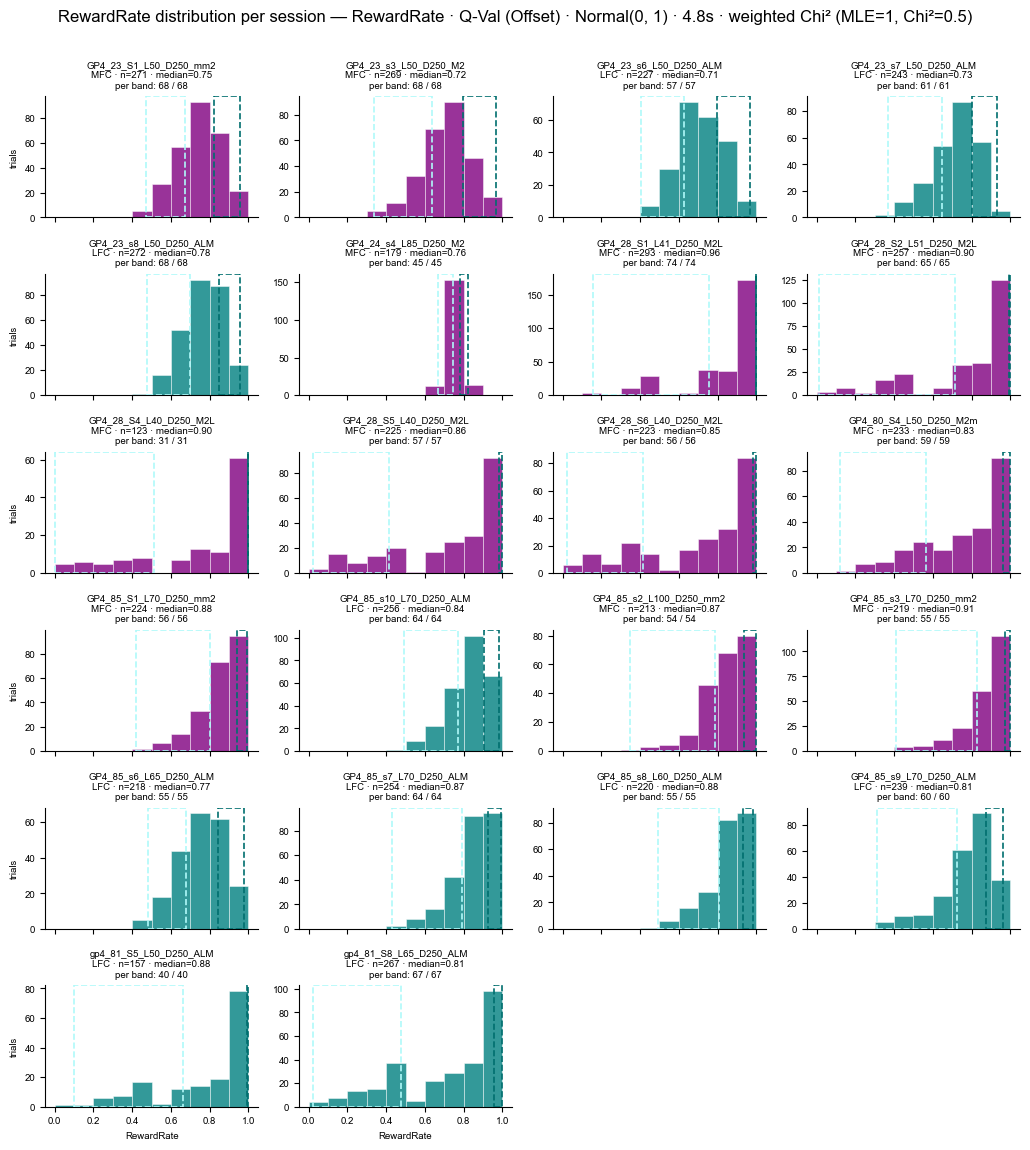

              ShortName BrainRegion  n_trials       p0      p25      p50      p75     p100 quantile_cuts n_per_fixed_bin usable_in_all_fixed              quantile_band_edges n_per_quantile_band  usable_in_all_bands
 GP4_23_S1_L50_D250_mm2         MFC       271 0.469920 0.669967 0.751619 0.823118 0.958957            []              []                None   [(0.47, 0.67), (0.823, 0.959)]            [68, 68]                 True
  GP4_23_s3_L50_D250_M2         MFC       269 0.337172 0.634246 0.716567 0.795798 0.966112            []              []                None [(0.337, 0.634), (0.796, 0.966)]            [68, 68]                 True
 GP4_23_s6_L50_D250_ALM         LFC       227 0.406923 0.627670 0.714962 0.798239 0.967398            []              []                None [(0.407, 0.628), (0.798, 0.967)]            [57, 57]                 True
 GP4_23_s7_L50_D250_ALM         LFC       243 0.368798 0.647720 0.733008 0.800782 0.932239            []              []                None

In [57]:
# Reward-rate distribution per session, bins=np.arange(0, 1.1, .1).
# This is the picture behind RR_SPLIT_BY: if the per-session histograms sit on
# top of each other, fixed cut points are fine; if they are shifted relative to
# one another (fitted latents usually are), a shared cut point hands each
# session a different number of trials per level.
#   RR_SPLIT_BY == "session_quantile_range" -> dashed OUTLINED spans are that
#       session's own quantile bands. How far they move panel to panel is
#       exactly the drift a fixed cut point would suffer. The "per band:" line
#       counts the session's trials in each band (unequal is expected: ties are
#       kept whole).
#   RR_SPLIT_BY == "session_quantile" -> dashed lines are that session's OWN
#       equal-count cuts; they move panel to panel, which is the point.
#   RR_SPLIT_BY == "value"            -> filled spans are the FIXED levels,
#       identical in every panel. The "per level:" line in each title counts the
#       session's trials in each level; a "!" flags a level it cannot contribute
#       to (< 3 trials -> no correlation computable -> session drops out).
_hist_fig, _rr_per_session = nc.plot_session_value_hist(
    table, "RewardRate", bins=np.arange(0, 1.1, .1),
    n_quantiles=(RR_QUANTILES if RR_SPLIT_BY == "session_quantile" else None),
    value_bins=(REWARD_RATE_BINS if RR_SPLIT_BY == "value" else None),
    quantile_ranges=(RR_QUANTILE_EXTREMES
                     if RR_SPLIT_BY == "session_quantile_range" else None),
    save=SAVE_FIGS, save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
print(_rr_per_session.to_string(index=False))


In [58]:
# Per-neuron DV / DVabs correlations, computed WITHIN each reward-rate level.
# `by=RR_SPLIT_BY` selects fixed cut points vs a per-session quantile split.
rr_bins, rr_tables, rr_corr = nc.reward_rate_correlations(
    table, REWARD_RATE_BINS, list(REWARD_RATE_PARAMS), by=RR_SPLIT_BY)
print("levels:", [b.label for b in rr_bins],
      " (neuron x trial) rows per level:", [len(t) for t in rr_tables])
print("trials per level:",
      [t.drop_duplicates(subset=["ShortName", "TrialNumber"]).shape[0]
       for t in rr_tables])
rr_corr[0].groupby(["BrainRegion", "ShortName"]).count()#.head()


levels: ['0-25% (low)', '75-100% (high)']  (neuron x trial) rows per level: [83894, 83894]
trials per level: [1279, 1279]


trace_id  long_trace_id  n_trials  DV_r  \
BrainRegion ShortName                                                          
LFC         GP4_23_s6_L50_D250_ALM         77             77        77    77   
            GP4_23_s7_L50_D250_ALM        106            106       106   106   
            GP4_23_s8_L50_D250_ALM         94             94        94    94   
            GP4_85_s10_L70_D250_ALM        38             38        38    38   
            GP4_85_s6_L65_D250_ALM         60             60        60    60   
            GP4_85_s7_L70_D250_ALM         69             69        69    69   
            GP4_85_s8_L60_D250_ALM         19             19        19    19   
            GP4_85_s9_L70_D250_ALM         62             62        62    62   
            gp4_81_S5_L50_D250_ALM         42             42        42    42   
            gp4_81_S8_L65_D250_ALM         42             42        42    42   
MFC         GP4_23_S1_L50_D250_mm2        165            165       165   165   
            GP4_23_s3_L50_D250_M2         122            122       122   122   
            GP4_24_s4_L85_D250_M2          32             32        32    32   
            GP4_28_S1_L41_D250_M2L         44             44        44    44   
            GP4_28_S2_L51_D250_M2L         63             63        63    63   
            GP4_28_S4_L40_D250_M2L         43             43        43    43   
            GP4_28_S5_L40_D250_M2L         56             56        56    56   
            GP4_28_S6_L40_D250_M2L         38             38        38    38   
            GP4_80_S4_L50_D250_M2m         45             45        45    45   
            GP4_85_S1_L70_D250_mm2         50             50        50    50   
            GP4_85_s2_L100_D250_mm2        50             50        50    50   
            GP4_85_s3_L70_D250_mm2         75             75        75    75   

                                     DV_p  
BrainRegion ShortName                      
LFC         GP4_23_s6_L50_D250_ALM     77  
            GP4_23_s7_L50_D250_ALM    106  
            GP4_23_s8_L50_D250_ALM     94  
            GP4_85_s10_L70_D250_ALM    38  
            GP4_85_s6_L65_D250_ALM     60  
            GP4_85_s7_L70_D250_ALM     69  
            GP4_85_s8_L60_D250_ALM     19  
            GP4_85_s9_L70_D250_ALM     62  
            gp4_81_S5_L50_D250_ALM     42  
            gp4_81_S8_L65_D250_ALM     42  
MFC         GP4_23_S1_L50_D250_mm2    165  
            GP4_23_s3_L50_D250_M2     122  
            GP4_24_s4_L85_D250_M2      32  
            GP4_28_S1_L41_D250_M2L     44  
            GP4_28_S2_L51_D250_M2L     63  
            GP4_28_S4_L40_D250_M2L     43  
            GP4_28_S5_L40_D250_M2L     56  
            GP4_28_S6_L40_D250_M2L     38  
            GP4_80_S4_L50_D250_M2m     45  
            GP4_85_S1_L70_D250_mm2     50  
            GP4_85_s2_L100_D250_mm2    50  
            GP4_85_s3_L70_D250_mm2     75

In [59]:
# WHERE DID THE SESSIONS GO? Sessions leave at three different places, each
# reported by a different helper — so a count looks unexplained when only one is
# consulted. This ledger holds EVERY recorded session and names the stage that
# lost it, so the arithmetic closes:
#   no model trials      -> never made it into `table` (subject has no fit, or
#                           the session's Date/SessionNum/TrialNumber match no
#                           MLE row). INVISIBLE to session_bin_coverage above,
#                           which only ever sees `table` — this is usually where
#                           the "rest of the missing sessions" are.
#   too few trials       -> under 3 trials in some bin, so no r is computable.
#   no assessable neuron -> trials enough, but every r came out undefined.
#   kept                 -> contributes to the paired across-bin test.
import pandas as pd

_att = nc.session_attrition(df_2p, table, "RewardRate", REWARD_RATE_BINS,
                            REWARD_RATE_PARAMS[0], corr_by_bin=rr_corr,
                            common_neurons=RR_COMMON_NEURONS, by=RR_SPLIT_BY)
print(f"{len(_att)} recorded sessions ->")
print(_att.attrs["counts"].to_string())
print()
print(_att.to_string(index=False))

# A subject WITH a fit whose session still matched nothing points at a date /
# session-number gap on the model side rather than an expected exclusion:
_lost = _att[_att.outcome == "no model trials"]
if len(_lost):
    print("\nDates present in the MLE latents vs in the 2-photon df:")
    for _sess in _lost.ShortName:
        _rows = df_2p[df_2p.ShortName == _sess]
        _subj = str(_rows.Name.iloc[0])
        _m = mle_pt[mle_pt.Name.astype(str) == _subj]
        _2p_dates = sorted(pd.to_datetime(_rows.Date).dt.date.unique())
        print(f"  {_sess} ({_subj}): 2p date {_2p_dates} · "
              + (f"MLE dates {sorted(pd.to_datetime(_m.Date).dt.date.unique())}"
                 if len(_m) else "subject ABSENT from the fit file"))


23 recorded sessions ->
BrainRegion  outcome        
LFC          kept               10
MFC          kept               12
             no model trials     1

              ShortName BrainRegion  n_trials_2p  n_trials_kept  n_0-25% (low)  n_75-100% (high)         outcome                      detail
 GP4_23_s6_L50_D250_ALM         LFC          227            227           57.0              57.0            kept                            
 GP4_23_s7_L50_D250_ALM         LFC          244            243           61.0              61.0            kept                            
 GP4_23_s8_L50_D250_ALM         LFC          272            272           68.0              68.0            kept                            
GP4_85_s10_L70_D250_ALM         LFC          256            256           64.0              64.0            kept                            
 GP4_85_s6_L65_D250_ALM         LFC          219            218           55.0              55.0            kept                        

=== Reward-rate summary for DV ===
	MFC & LFC: 0-25% (low) 3.9±0.9% (22 sess) | 75-100% (high) 5.3±1.4% (22 sess)
	  across bins: paired t(21) = -0.76, p = 0.456  [22 of 22 sessions paired]


c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


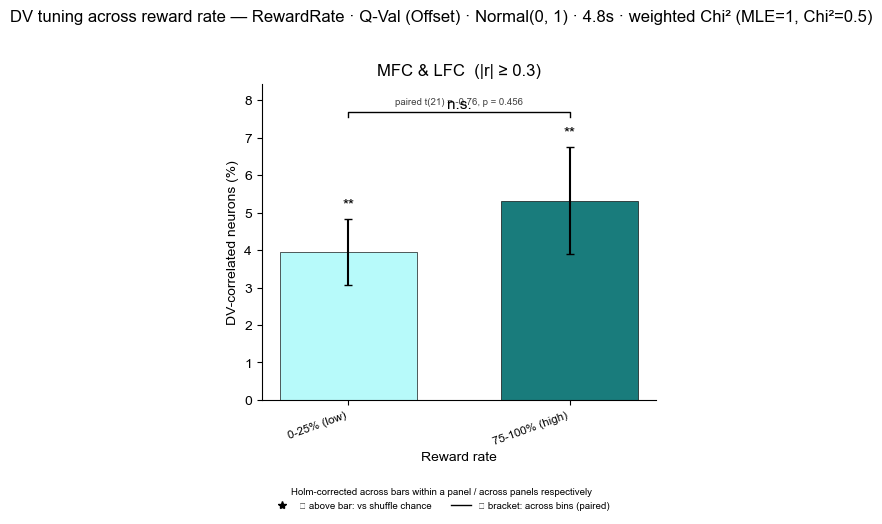

BrainRegion               ShortName            bin       pct  n_trials  n_neurons  trials_per_neuron paired
  MFC & LFC  GP4_23_S1_L50_D250_mm2    0-25% (low)  2.424242        68        165               68.0   True
  MFC & LFC   GP4_23_s3_L50_D250_M2    0-25% (low)  2.459016        68        122               68.0   True
  MFC & LFC  GP4_23_s6_L50_D250_ALM    0-25% (low)  1.298701        57         77               57.0   True
  MFC & LFC  GP4_23_s7_L50_D250_ALM    0-25% (low)  8.490566        61        106               61.0   True
  MFC & LFC  GP4_23_s8_L50_D250_ALM    0-25% (low)  4.255319        68         94               68.0   True
  MFC & LFC   GP4_24_s4_L85_D250_M2    0-25% (low)  3.125000        45         32               45.0   True
  MFC & LFC  GP4_28_S1_L41_D250_M2L    0-25% (low)  0.000000        74         44               74.0   True
  MFC & LFC  GP4_28_S2_L51_D250_M2L    0-25% (low)  4.761905        65         63               65.0   True
  MFC & LFC  GP4_28_S4_L40_D

In [60]:
# Reward-rate summary bars: per region (one panel per MFC/LFC) and all-regions
# pooled, for each correlate. Passing `bin_tables` enables the per-bar vs-chance
# shuffle test; the bracket over the bins is the session-paired across-bin test
# (paired t-test for 2 bins, RM-ANOVA + Holm post-hocs beyond). Set
# RUN_STATS=False in Config for a fast plot-only pass.
rr_summaries = {}
for _param in REWARD_RATE_PARAMS:
        if _param == "DVabs":
            continue
        print(f"=== Reward-rate summary for {_param} ===")
        _by_region = False
    # for _by_region in (True, False):
        rr_summaries[(_param, _by_region)] = nc.plot_reward_rate_bars(
            rr_corr, rr_bins, _param, bin_tables=rr_tables,
            min_abs_corr=MIN_ABS_CORR, n_perm=N_PERM, by_region=_by_region,
            run_stats=RUN_STATS, common_neurons=RR_COMMON_NEURONS,
            save=SAVE_FIGS, save_root=BASE_SAVE_PATH,
            model_name=MODEL_NAME)
rr_summaries[(REWARD_RATE_PARAMS[0], _by_region)]

# `rr_summaries` rows are keyed by `scope`:
#   "bin"        -> the bars (one per region x level)
#   "session"    -> the per-session detail BEHIND each bar: that
#                   session's pct, n_trials, n_neurons,
#                   trials_per_neuron and whether it was paired
#   "comparison" -> pairwise post-hocs (>2 levels)
_s = rr_summaries[(REWARD_RATE_PARAMS[0], _by_region)]
print(_s[_s.scope == "session"][["BrainRegion", "ShortName", "bin",
      "pct", "n_trials", "n_neurons", "trials_per_neuron",
      "paired"]].to_string(index=False))


## Paired per-neuron correlation strength

The bar charts count *how many* neurons clear `MIN_ABS_CORR`, which discards the
size of each correlation. Here we keep the `r` itself and compare it **within
neuron** across two conditions — more sensitive, and no threshold is applied at
test time.

The neuron set is fixed once: neurons DV-correlated (`|r| >= MIN_ABS_CORR`) in
**either** the fast or the slow subset. The *same* set is then used for both
plots, so the two comparisons are about the same population.

`|r|` (strength) is plotted rather than signed `r`: the set contains both
positively and negatively DV-tuned neurons, and a signed average over them sits
near zero in both conditions, so a signed test would compare two nulls.

Each plot annotates a **paired t-test across neurons**, and prints a second
paired t-test across **session means** — neurons within a session are not
independent, so the across-neuron `p` is anti-conservative; prefer the
across-session one when they disagree.

Note the two plots differ in how much they can be trusted. Plot 1 compares the
very conditions the neurons were *selected* on, so regression to the mean will
pull each neuron toward the middle in whichever condition did not drive its
selection — some difference is manufactured by the selection itself. Plot 2
compares reward-rate levels, a split the selection knew nothing about, so it does
not have that problem.

Each condition is a bar (mean ± SEM across neurons) with one grey line per
neuron drawn over it, so the group effect and the pairing behind it are both
visible. Every plot is repeated in the next cell **split by brain region**, with
each panel tested on its own neurons.


70 neurons DV-correlated in fast OR slow (|r| >= 0.3)
  pairable in both speeds: 70 (dropped 0 with an undefined r)
	fast 0.190±0.015  vs  slow 0.302±0.015   (n=70 neurons)
	  across neurons: paired t(69) = -4.20, p < 0.001
	  across sessions (guards against pseudo-replication): paired t(19) = -2.12, p = 0.047


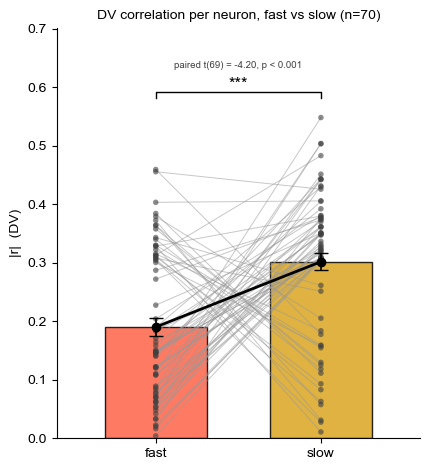

In [61]:
# The neuron set, fixed once and reused by both plots: DV-correlated in EITHER
# the fast or the slow subset.
DV_NEURONS = nc.select_tuned_neurons([corr_fast, corr_slow], "DV",
                                     min_abs_corr=MIN_ABS_CORR)
print(f"{len(DV_NEURONS)} neurons DV-correlated in fast OR slow "
      f"(|r| >= {MIN_ABS_CORR})")

# Plot 1 - the same neurons' |r| in fast vs slow.
_paired_fs = nc.paired_neuron_r(corr_fast, corr_slow, "DV", neurons=DV_NEURONS)
print(f"  pairable in both speeds: {len(_paired_fs)}"
      f" (dropped {_paired_fs.attrs.get('n_missing', 0)} with an undefined r)")
_fig_fs, _stats_fs = nc.plot_paired_neuron_r(
    _paired_fs, ("fast", "slow"), "DV", bar_colors=nc.FAST_SLOW_COLORS,
    title=f"DV correlation per neuron, fast vs slow (n={len(_paired_fs)})",
    save=SAVE_FIGS, save_root=BASE_SAVE_PATH, model_name=MODEL_NAME,
    tag="DV_fast_vs_slow")


[LFC] fast 0.183±0.027  vs  slow 0.315±0.018   (n=27 neurons)
	  across neurons: paired t(26) = -3.51, p = 0.002
	  across sessions (guards against pseudo-replication): paired t(8) = -1.01, p = 0.340
[MFC] fast 0.195±0.018  vs  slow 0.294±0.022   (n=43 neurons)
	  across neurons: paired t(42) = -2.70, p = 0.010
	  across sessions (guards against pseudo-replication): paired t(10) = -1.94, p = 0.081


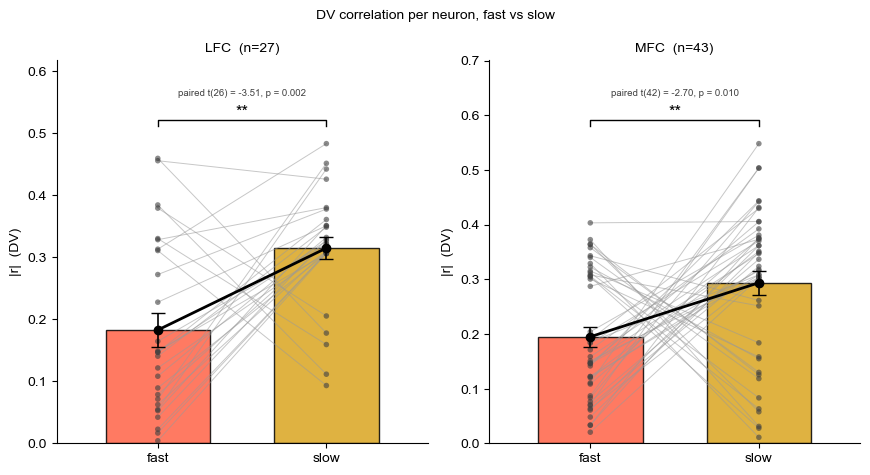

In [62]:
# Plot 1, split by brain region: the same neurons and the same test, but MFC
# and LFC drawn and tested separately. Panels are NOT cross-region corrected —
# they are two analyses of two populations, not one family of tests.
_fig_fs_r, _stats_fs_r = nc.plot_paired_neuron_r(
    _paired_fs, ("fast", "slow"), "DV", by_region=True,
    bar_colors=nc.FAST_SLOW_COLORS,
    title="DV correlation per neuron, fast vs slow",
    save=SAVE_FIGS, save_root=BASE_SAVE_PATH, model_name=MODEL_NAME,
    tag="DV_fast_vs_slow")


70 of the 70 DV neurons are pairable across 0-25% (low) vs 75-100% (high)
	0-25% (low) 0.171±0.014  vs  75-100% (high) 0.220±0.016   (n=70 neurons)
	  across neurons: paired t(69) = -2.46, p = 0.016
	  across sessions (guards against pseudo-replication): paired t(19) = -0.79, p = 0.437


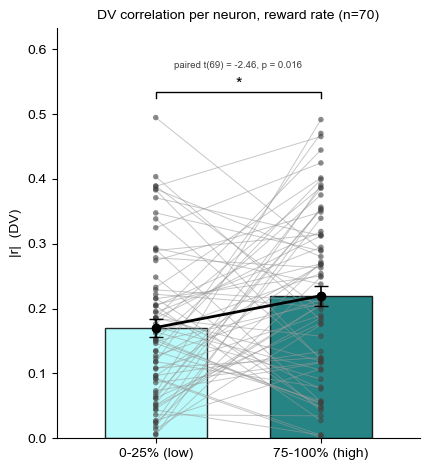

In [63]:
# Plot 2 - the SAME neurons' |r| at low vs high reward rate. With more than two
# levels the first and last are used, which is the low-vs-high contrast.
_rr_low, _rr_high = rr_corr[0], rr_corr[-1]
_lo_lab, _hi_lab = rr_bins[0].label, rr_bins[-1].label
_paired_rr = nc.paired_neuron_r(_rr_low, _rr_high, "DV", neurons=DV_NEURONS)
print(f"{len(_paired_rr)} of the {len(DV_NEURONS)} DV neurons are pairable "
      f"across {_lo_lab} vs {_hi_lab}")
_fig_rr, _stats_rr = nc.plot_paired_neuron_r(
    _paired_rr, (_lo_lab, _hi_lab), "DV",
    bar_colors=nc.reward_rate_colors(),
    title=f"DV correlation per neuron, reward rate (n={len(_paired_rr)})",
    save=SAVE_FIGS, save_root=BASE_SAVE_PATH, model_name=MODEL_NAME,
    tag="DV_low_vs_high_rewardrate")


[LFC] 0-25% (low) 0.187±0.023  vs  75-100% (high) 0.210±0.023   (n=27 neurons)
	  across neurons: paired t(26) = -0.83, p = 0.414
	  across sessions (guards against pseudo-replication): paired t(8) = -0.98, p = 0.354
[MFC] 0-25% (low) 0.160±0.017  vs  75-100% (high) 0.226±0.021   (n=43 neurons)
	  across neurons: paired t(42) = -2.39, p = 0.022
	  across sessions (guards against pseudo-replication): paired t(10) = -0.31, p = 0.762


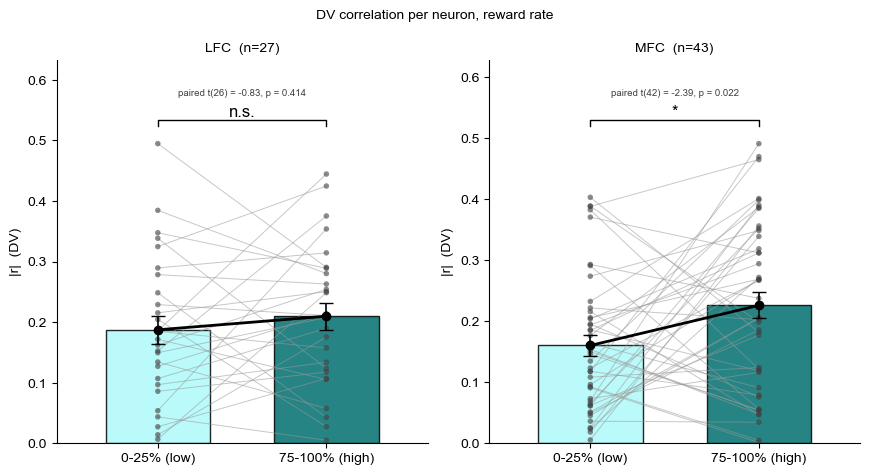

In [64]:
# Plot 2, split by brain region.
_fig_rr_r, _stats_rr_r = nc.plot_paired_neuron_r(
    _paired_rr, (_lo_lab, _hi_lab), "DV", by_region=True,
    bar_colors=nc.reward_rate_colors(),
    title="DV correlation per neuron, reward rate",
    save=SAVE_FIGS, save_root=BASE_SAVE_PATH, model_name=MODEL_NAME,
    tag="DV_low_vs_high_rewardrate")
